# DIMER Guided Notebook: Comparing Closed-Set Object Detectors

**Profile:** `E2E`  
**Mode:** `WORKSHOP`  
**Notebook specification:** `2.1`  
**Status:** Candidate comparative carrier  
**Default tier:** `STANDARD`  
**Canonical runtime:** NVIDIA Tesla T4 or equivalent

This notebook compares closed-vocabulary object detectors on **one controlled downstream detection task**:

- **RT-DETR R50-VD** — transformer / set-prediction detector
- **YOLOX-S** — lightweight anchor-free dense detector
- **YOLOX-X** — large YOLOX scale experiment (`FULL` tier)

The experiment controls what can meaningfully be controlled:

> **same pixels → same boxes → same class vocabulary → same 36/12/12 split → same common evaluator**

while preserving what should remain architecture-specific:

> **preprocessing semantics → detection formulation → assignment algorithm → loss → optimizer → adaptation scope**

### Canonical question

> How do set-prediction and dense anchor-free detectors transfer differently to the same small closed-vocabulary detection problem, and what accuracy/compute tradeoffs emerge once the data and evaluation are controlled?

### Standalone behavior

The notebook does not:

- clone a DIMER repository;
- import or download DIMER repository source;
- call DIMER workers/services;
- require credentials;
- require an upload on the default path.

RT-DETR runs through the pinned `transformers` implementation.

YOLOX carries nine verified upstream files that form eight runtime modules at immutable revision `419778480ab6ec0590e5d3831b3afb3b46ab2aa3`, including the Apache-2.0 license and original notices. Model checkpoints still download from pinned sources. Release remains pending fresh STANDARD/FULL T4 and real-model BYOD qualification.

All built-in results are **synthetic tutorial/sample-sanity evidence**, not evidence of real traffic-sign detection performance.

## 0. Learning goals

By the end of this notebook, participants should be able to:

1. distinguish image classification from object detection;
2. explain set-prediction detection versus dense objectness-based detection;
3. interpret IoU, AP, AP50, and AP75;
4. understand why raw detector scores are not calibrated probabilities;
5. adapt pretrained COCO detectors to a new three-class vocabulary;
6. explain why RT-DETR and YOLOX should keep different native training objectives;
7. preserve train/validation/test ownership;
8. compare localization quality rather than AP50 alone;
9. inspect size, density, class-confusion, and threshold effects;
10. export and fresh-reload adapted detector artifacts; and
11. understand when closed-set detection is the wrong tool and an open-vocabulary detector is needed.

**Concept — Input → Model → Output:** labelled sign images → pretrained detector with a three-class head and bounded adaptation → boxes, labels and confidence scores. Validation guides interpretation; freeze the recipe before opening the test results. Basic Python and Colab familiarity is sufficient.


**How to use this notebook:** no prior ML experience is required. In Colab choose Runtime → Change runtime type → T4 GPU, then run sections in order (or Run all for the default path). Keep `STANDARD` and BYOD disabled for the first run. Follow the data gallery → baseline → adaptation → validation → freeze → test → interpretation → export sequence. Pause at prediction prompts when learning interactively. Runtime and VRAM are measured by the notebook; supported-runtime duration has not yet been qualified, so reserve an uninterrupted GPU session rather than relying on an unmeasured time estimate.


## 1. Notebook controls

In [1]:
# @title Notebook controls
WORKSHOP_TIER = "STANDARD"  # @param ["STANDARD", "FULL"]

USE_BYOD = False            # @param {type:"boolean"}
BYOD_ZIP_PATH = ""          # @param {type:"string"}

OUTPUT_DIR = "outputs"      # @param {type:"string"}

DATASET_IMAGES = 60
DATASET_SEED = 0
SPLIT_SEED = 42
NEW_DATA_SEED = 2026

RTDETR_EPOCHS = 3
RTDETR_BATCH_SIZE = 4
RTDETR_LEARNING_RATE = 1e-4

YOLOX_EPOCHS = 6
YOLOX_BATCH_SIZE = 2
YOLOX_LEARNING_RATE = 1e-3

EVAL_SCORE_THRESHOLD = 0.01
YOLOX_EVAL_NMS = 0.65
DISPLAY_THRESHOLD = 0.30
MAX_EVAL_DETECTIONS = 100
IOU_THRESHOLDS = tuple(round(0.50 + 0.05*i, 2) for i in range(10))
CLASS_NAMES = ("stop-sign", "yield-sign", "speed-limit-sign")

if WORKSHOP_TIER not in {"STANDARD", "FULL"}:
    raise ValueError("WORKSHOP_TIER must be STANDARD or FULL")
if DATASET_IMAGES != 60:
    raise ValueError("Canonical fixture is pinned to 60 images")
if not 0 <= EVAL_SCORE_THRESHOLD <= 1:
    raise ValueError("EVAL_SCORE_THRESHOLD outside [0,1]")

MODEL_KEYS = ["rtdetr", "yolox_s"] + (["yolox_x"] if WORKSHOP_TIER == "FULL" else [])

from pathlib import Path
OUTPUT_ROOT = Path(OUTPUT_DIR)
WORK_ROOT = Path("work")

for path in [
    OUTPUT_ROOT / "data",
    OUTPUT_ROOT / "pre_adaptation",
    OUTPUT_ROOT / "adaptation",
    OUTPUT_ROOT / "validation",
    OUTPUT_ROOT / "frozen",
    OUTPUT_ROOT / "test",
    OUTPUT_ROOT / "artifacts",
    OUTPUT_ROOT / "figures",
    OUTPUT_ROOT / "new_data",
    OUTPUT_ROOT / "provenance",
    WORK_ROOT / "rtdetr_weights",
    WORK_ROOT / "yolox_weights",
    WORK_ROOT / "yolox_upstream",
    WORK_ROOT / "byod",
]:
    path.mkdir(parents=True, exist_ok=True)

print({
    "tier": WORKSHOP_TIER,
    "models": MODEL_KEYS,
    "dataset_images": DATASET_IMAGES,
    "classes": CLASS_NAMES,
    "split_seed": SPLIT_SEED,
})

{'tier': 'STANDARD', 'models': ['rtdetr', 'yolox_s'], 'dataset_images': 60, 'classes': ('stop-sign', 'yield-sign', 'speed-limit-sign'), 'split_seed': 42}


## 2. Install one common runtime

RT-DETR needs Transformers.

YOLOX uses only PyTorch, torchvision, NumPy, and Pillow once its pinned upstream model modules have been staged.

The package union remains small enough for a single Python 3.12 environment.

In [2]:
# @title Install pinned runtime
import importlib
import importlib.metadata
import os
import platform
import subprocess
import sys

PINS = [
    "torch==2.14.0",
    "torchvision==0.29.0",
    "torchaudio==2.11.0",
    "transformers==4.57.6",
    "safetensors==0.8.0",
    "numpy==2.1.3",
    "pillow==11.3.0",
    "huggingface-hub==0.36.2",
    "scipy==1.18.1",  # RT-DETR training loss: Transformers' Hungarian matcher needs SciPy
    "matplotlib>=3.9,<3.11",
    "pandas>=2.2,<3.1",
]

SKIP_INSTALL = os.environ.get("DIMER_NOTEBOOK_CI_PREINSTALLED") == "1"

# Hosted kernels such as Colab import NumPy at startup. Replacing a loaded module on disk would force a manual
# restart (Notebook Spec RUN10), so a NumPy 2.x that is already loaded is kept and recorded instead of reinstalled.
NUMPY_PRELOADED = None
if "numpy" in sys.modules and str(getattr(sys.modules["numpy"], "__version__", "")).startswith("2."):
    NUMPY_PRELOADED = sys.modules["numpy"].__version__
    PINS = [f"numpy=={NUMPY_PRELOADED}" if pin.startswith("numpy==") else pin for pin in PINS]

# Inspect already imported packages before pip can replace their on-disk files.
from packaging.version import Version
LOADED_VERSIONS={name:getattr(sys.modules.get(module),"__version__",None)
                 for name,module in {"torch":"torch","torchvision":"torchvision",
                     "torchaudio":"torchaudio","numpy":"numpy","transformers":"transformers",
                     "pillow":"PIL","scipy":"scipy","safetensors":"safetensors",
                     "huggingface-hub":"huggingface_hub"}.items()}

def stale_loaded_packages(loaded,pins):
    expected=dict(pin.split("==",1) for pin in pins if "==" in pin)
    return [name for name,value in loaded.items() if value is not None and name in expected
            and Version(str(value)).public!=Version(expected[name]).public]

if not SKIP_INSTALL:
    completed = subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", *PINS],
        check=False, text=True, capture_output=True,
    )
    if completed.returncode != 0:
        raise RuntimeError(
            f"pip install failed with exit code {completed.returncode}.\n"
            f"--- stderr (tail) ---\n{completed.stderr[-4000:]}\n"
            f"--- stdout (tail) ---\n{completed.stdout[-2000:]}"
        )
    importlib.invalidate_caches()

# Fail closed rather than run with a module whose files were replaced underneath it.
stale = [
    (name, sys.modules[name].__version__, importlib.metadata.version(name))
    for name in ("numpy", "torch")
    if name in sys.modules
    and str(sys.modules[name].__version__).split("+")[0] != importlib.metadata.version(name).split("+")[0]
]
if stale:
    raise RuntimeError(
        "The kernel had already imported packages that the pinned install replaced on disk. "
        "Restart the Python session and choose Run all again (Colab: Runtime > Restart session; "
        f"do not delete the runtime, which discards the installed pins). Stale modules: {stale}"
    )
print("numpy:", "preloaded by the host kernel" if NUMPY_PRELOADED else "pinned install", sys.modules.get("numpy") and sys.modules["numpy"].__version__)

stale=stale_loaded_packages(LOADED_VERSIONS,PINS)
if stale:
    raise RuntimeError(f"Restart session, then run this cell again: loaded packages differ from pins: {stale}. "
                       "This is a session restart, not deletion of the runtime. Record the restart for qualification.")

import numpy as np
import pandas as pd
import torch
import torchvision
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont, ImageOps

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

print({
    "python": platform.python_version(),
    "torch": torch.__version__,
    "torchvision": torchvision.__version__,
    "transformers": importlib.metadata.version("transformers"),
    "device": DEVICE,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
})

numpy: preloaded by the host kernel 2.1.3
{'python': '3.13.15', 'torch': '2.14.0+cu130', 'torchvision': '0.29.0+cu130', 'transformers': '4.57.6', 'device': 'cuda:0', 'gpu': 'Tesla T4'}


# 3. Model identities

## RT-DETR R50-VD

- Model: `PekingU/rtdetr_r50vd`
- Revision: `df939e661d8c52e80608d1ec566561aabd25a4e7`
- License: Apache-2.0
- Approx. parameters: 42.7M
- Architecture: ResNet-50-vd → hybrid encoder → 6-layer deformable transformer decoder → 300 learned object queries
- Original vocabulary: 80 COCO classes
- Preprocessing: RT-DETR's pinned 640×640 processor

Pinned SafeTensors:

`model.safetensors`  
172,175,856 bytes  
SHA-256 `5263d5521eff3e356f6cd8a371fd5dfb891725beda5f713674f79669115cdc64`

## YOLOX-S

- Release: Megvii YOLOX `0.1.1rc0`
- Upstream code revision: `419778480ab6ec0590e5d3831b3afb3b46ab2aa3`
- License: Apache-2.0
- Parameters: 8,968,255
- 640×640 anchor-free candidate grid: 8,400 locations

Checkpoint:

`yolox_s.pth`  
72,089,125 bytes  
SHA-256 `f55ded7181e1b0c13285c56e7790b8f0e8f8db590fe4edb37f0b7f345c913a30`

## YOLOX-X (`FULL` only)

- Parameters: 99,071,455
- Depth 1.33 / width 1.25

Checkpoint:

`yolox_x.pth`  
793,463,373 bytes  
SHA-256 `5652330b6ae860043f091b8f550a60c10e1129f416edfdb65c259be6caf355cf`

In [3]:
# @title Immutable model specifications
RTDETR_SPEC = {
    "model_id": "PekingU/rtdetr_r50vd",
    "revision": "df939e661d8c52e80608d1ec566561aabd25a4e7",
    "files": {
        "README.md": (9053, "4a0c10ddd0dbf6a2c6815cfc1613a5d74f3b0e7c8c77f0252212d3e5365e98cb"),
        "config.json": (5113, "2ed2a305c51eef46715eb755a02b2a266ecfb752936cc9574bb5714601c2742d"),
        "model.safetensors": (172175856, "5263d5521eff3e356f6cd8a371fd5dfb891725beda5f713674f79669115cdc64"),
        "preprocessor_config.json": (841, "ffb4b9461a1dad746be8f0f9c8330ed7743a1ba5fba4f75c232cd281b3d4c64a"),
    },
}

YOLOX_VARIANTS = {
    "yolox_s": {
        "display_name": "YOLOX-S",
        "depth": 0.33,
        "width": 0.50,
        "parameters_reference": 8_968_255,
        "checkpoint": "yolox_s.pth",
        "bytes": 72_089_125,
        "sha256": "f55ded7181e1b0c13285c56e7790b8f0e8f8db590fe4edb37f0b7f345c913a30",
        "url": "https://github.com/Megvii-BaseDetection/YOLOX/releases/download/0.1.1rc0/yolox_s.pth",
    },
    "yolox_x": {
        "display_name": "YOLOX-X",
        "depth": 1.33,
        "width": 1.25,
        "parameters_reference": 99_071_455,
        "checkpoint": "yolox_x.pth",
        "bytes": 793_463_373,
        "sha256": "5652330b6ae860043f091b8f550a60c10e1129f416edfdb65c259be6caf355cf",
        "url": "https://github.com/Megvii-BaseDetection/YOLOX/releases/download/0.1.1rc0/yolox_x.pth",
    },
}

# 4. Build one deterministic 60-image closed-set detection task

This notebook uses its own synthetic traffic-sign generator derived from the existing DIMER RT-DETR and YOLOX fixtures.

Target vocabulary:

- `stop-sign`
- `yield-sign`
- `speed-limit-sign`

All images are exactly **640×640**.

That is important:

- RT-DETR normally squashes arbitrary inputs to 640×640;
- YOLOX normally preserves aspect ratio and letterboxes to 640×640.

For this canonical fixture, both see the same 640×640 source geometry, removing a major preprocessing confound.

In [4]:
# @title Deterministic sign generator
import math
import hashlib
import io
import json

SCENE_SIZE = (640, 640)
MAX_OBJECTS = 3

def _font(size=22):
    try:
        return ImageFont.truetype("DejaVuSans-Bold.ttf", size)
    except Exception:
        return ImageFont.load_default()

def _stop_sign(draw, cx, cy, r):
    pts = []
    for i in range(8):
        angle = math.radians(22.5 + 45*i)
        pts.append((cx + r*math.cos(angle), cy + r*math.sin(angle)))
    draw.polygon(pts, fill=(195, 28, 35), outline="white")
    draw.line(pts + [pts[0]], fill="white", width=5)
    font = _font(max(12, int(r*0.34)))
    text = "STOP"
    bbox = draw.textbbox((0,0), text, font=font)
    tw, th = bbox[2]-bbox[0], bbox[3]-bbox[1]
    draw.text((cx-tw/2, cy-th/2), text, fill="white", font=font)
    xs, ys = zip(*pts)
    return [min(xs), min(ys), max(xs), max(ys)]

def _yield_sign(draw, cx, cy, r):
    pts = [
        (cx, cy-r),
        (cx-r*0.92, cy+r*0.72),
        (cx+r*0.92, cy+r*0.72),
    ]
    draw.polygon(pts, fill="white", outline=(205,30,35))
    draw.line(pts + [pts[0]], fill=(205,30,35), width=8)
    xs, ys = zip(*pts)
    return [min(xs), min(ys), max(xs), max(ys)]

def _speed_limit_sign(draw, cx, cy, r, limit):
    w, h = r*1.28, r*1.55
    box = [cx-w/2, cy-h/2, cx+w/2, cy+h/2]
    draw.rounded_rectangle(box, radius=max(5,int(r*0.08)), fill="white", outline="black", width=5)
    font1 = _font(max(10,int(r*0.22)))
    font2 = _font(max(18,int(r*0.45)))
    title = "SPEED"
    tb = draw.textbbox((0,0), title, font=font1)
    draw.text((cx-(tb[2]-tb[0])/2, cy-h*0.33), title, fill="black", font=font1)
    text = str(limit)
    nb = draw.textbbox((0,0), text, font=font2)
    draw.text((cx-(nb[2]-nb[0])/2, cy-(nb[3]-nb[1])/2+5), text, fill="black", font=font2)
    return box

def generate_sign_dataset(n_images=60, seed=0, max_objects=3):
    if not 1 <= n_images <= 500:
        raise ValueError("n_images outside 1..500")
    rng = np.random.default_rng(seed)
    width, height = SCENE_SIZE
    slots = [(x, y) for y in (150, 400) for x in (140, 360, 560)]
    records = []

    for image_index in range(n_images):
        image = Image.new("RGB", SCENE_SIZE, (232,236,240))
        draw = ImageDraw.Draw(image)
        tint = rng.integers(200,245,3)
        draw.rectangle([0,0,width,height], fill=tuple(int(v) for v in tint))
        draw.rectangle([0,int(height*0.72),width,height], fill=(118,122,126))

        n_objects = int(rng.integers(1,max_objects+1))
        chosen = rng.permutation(len(slots))[:n_objects]
        boxes, labels = [], []

        for slot_index in chosen:
            cx, cy = slots[int(slot_index)]
            cx += float(rng.integers(-28,29))
            cy += float(rng.integers(-28,29))
            radius = float(rng.integers(46,71))
            cx = min(max(cx, radius+6), width-radius-6)
            cy = min(max(cy, radius+6), height-radius-100)

            kind = CLASS_NAMES[int(rng.integers(0,len(CLASS_NAMES)))]
            draw.rectangle(
                [cx-5, cy+radius*0.6, cx+5, min(height-1, cy+radius+90)],
                fill=(112,112,116),
            )

            if kind == "stop-sign":
                box = _stop_sign(draw,cx,cy,radius)
            elif kind == "yield-sign":
                box = _yield_sign(draw,cx,cy,radius)
            else:
                box = _speed_limit_sign(draw,cx,cy,radius,int(rng.choice([30,50,60,80])))

            boxes.append([
                float(max(0,box[0])), float(max(0,box[1])),
                float(min(width,box[2])), float(min(height,box[3])),
            ])
            labels.append(kind)

        buf = io.BytesIO()
        image.save(buf, format="PNG")
        pixel_sha = hashlib.sha256(buf.getvalue()).hexdigest()
        ann_sha = hashlib.sha256(
            json.dumps({"boxes":boxes,"labels":labels}, separators=(",",":")).encode()
        ).hexdigest()

        records.append({
            "id": f"sign-{image_index:03d}",
            "image": image,
            "boxes": boxes,
            "labels": labels,
            "pixel_sha256": pixel_sha,
            "annotation_sha256": ann_sha,
        })

    return records

all_records = generate_sign_dataset(DATASET_IMAGES, DATASET_SEED, MAX_OBJECTS)

print({
    "images": len(all_records),
    "boxes": sum(len(r["boxes"]) for r in all_records),
    "class_counts": {
        name: sum(label==name for r in all_records for label in r["labels"])
        for name in CLASS_NAMES
    },
})

{'images': 60, 'boxes': 120, 'class_counts': {'stop-sign': 29, 'yield-sign': 48, 'speed-limit-sign': 43}}


# 5. Deterministic 36 / 12 / 12 split and validation

No test image is used for training or model selection.

The notebook additionally checks:

- box geometry;
- image dimensions;
- class membership;
- class coverage in all three splits;
- no duplicate image bytes across splits.

In [5]:
# @title Split and validate records
def split_records(records, seed=42):
    rng = np.random.default_rng(seed)
    order = rng.permutation(len(records))
    train_ids = set(order[:36].tolist())
    val_ids = set(order[36:48].tolist())
    test_ids = set(order[48:60].tolist())

    result = {"train":[], "validation":[], "test":[]}
    for i, record in enumerate(records):
        split = "train" if i in train_ids else "validation" if i in val_ids else "test"
        result[split].append({**record, "split":split})
    return result

def validate_records(records, class_names):
    seen_ids=set()
    seen_pixels=set()
    class_counts={name:0 for name in class_names}

    for r in records:
        if r["id"] in seen_ids:
            raise ValueError(f"duplicate id {r['id']}")
        seen_ids.add(r["id"])
        if r["pixel_sha256"] in seen_pixels:
            raise ValueError(f"duplicate image bytes at {r['id']}")
        seen_pixels.add(r["pixel_sha256"])

        if r["image"].size != SCENE_SIZE:
            raise ValueError(f"{r['id']}: canonical sample must be 640x640")
        if len(r["boxes"]) != len(r["labels"]) or not r["boxes"]:
            raise ValueError(f"{r['id']}: boxes/labels invalid")

        for box,label in zip(r["boxes"],r["labels"]):
            if label not in class_names:
                raise ValueError(f"{r['id']}: unknown label {label}")
            if len(box)!=4 or not np.isfinite(box).all():
                raise ValueError(f"{r['id']}: invalid box {box}")
            x0,y0,x1,y1=map(float,box)
            if not (0<=x0<x1<=640 and 0<=y0<y1<=640):
                raise ValueError(f"{r['id']}: out-of-bounds box {box}")
            class_counts[label]+=1
    return class_counts

splits = split_records(all_records, SPLIT_SEED)
for split_name, rows in splits.items():
    counts = validate_records(rows, CLASS_NAMES)
    missing=[k for k,v in counts.items() if v==0]
    if missing:
        raise RuntimeError(f"canonical split {split_name} lacks classes {missing}")
    print(split_name, len(rows), counts)

# Cross-split pixel leak check.
digest_to_split={}
for split_name, rows in splits.items():
    for r in rows:
        prior=digest_to_split.get(r["pixel_sha256"])
        if prior and prior!=split_name:
            raise RuntimeError(f"pixel content leaks across {prior}/{split_name}")
        digest_to_split[r["pixel_sha256"]]=split_name

train_records=splits["train"]
validation_records=splits["validation"]
test_records=splits["test"]

dataset_manifest = {
    "generator": "dimer-closed-set-signs-v1",
    "generator_seed": DATASET_SEED,
    "split_seed": SPLIT_SEED,
    "image_size": list(SCENE_SIZE),
    "class_names": list(CLASS_NAMES),
    "n_images": len(all_records),
    "n_boxes": sum(len(r["boxes"]) for r in all_records),
    "splits": {
        name: {
            "image_ids":[r["id"] for r in rows],
            "n_images":len(rows),
            "n_boxes":sum(len(r["boxes"]) for r in rows),
        }
        for name,rows in splits.items()
    },
    "images": [
        {
            "id":r["id"],
            "pixel_sha256":r["pixel_sha256"],
            "annotation_sha256":r["annotation_sha256"],
            "split":r["split"],
        }
        for rows in splits.values() for r in rows
    ],
}
dataset_manifest["dataset_sha256"] = hashlib.sha256(
    json.dumps(dataset_manifest["images"],sort_keys=True,separators=(",",":")).encode()
).hexdigest()

(OUTPUT_ROOT/"data"/"dataset_manifest.json").write_text(
    json.dumps(dataset_manifest,indent=2),encoding="utf-8"
)

print("dataset_sha256",dataset_manifest["dataset_sha256"])

train 36 {'stop-sign': 12, 'yield-sign': 35, 'speed-limit-sign': 26}
validation 12 {'stop-sign': 10, 'yield-sign': 6, 'speed-limit-sign': 9}
test 12 {'stop-sign': 7, 'yield-sign': 7, 'speed-limit-sign': 8}
dataset_sha256 823df4cf634db78216dccf5a6988171248b844beb5303ecc8c1f1b80ca302169


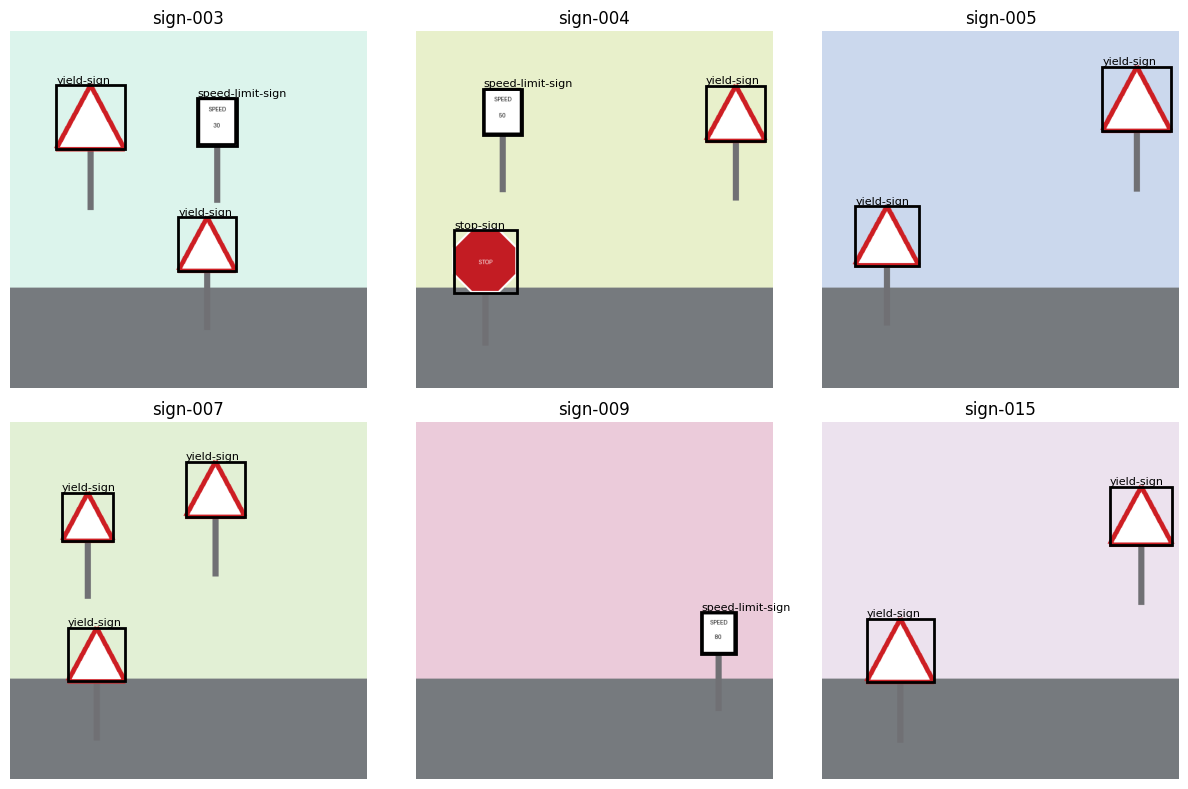

In [6]:
# @title Dataset gallery
fig, axes = plt.subplots(2,3,figsize=(12,8))
for ax,record in zip(axes.ravel(),train_records[:6]):
    ax.imshow(record["image"])
    for box,label in zip(record["boxes"],record["labels"]):
        x0,y0,x1,y1=box
        rect=plt.Rectangle((x0,y0),x1-x0,y1-y0,fill=False,linewidth=2)
        ax.add_patch(rect)
        ax.text(x0,y0-4,label,fontsize=8)
    ax.set_title(record["id"])
    ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_ROOT/"figures"/"dataset_gallery.png",dpi=150,bbox_inches="tight")
plt.show()

# 6. Common detector evaluator

The evaluator is notebook-owned and receives only normalized predictions:

```text
[
  {"box":[x0,y0,x1,y1], "label":"stop-sign", "score":0.73},
  ...
]
```

It implements class-aware one-to-one matching, 101-point interpolated AP, and IoU thresholds 0.50:0.05:0.95.

These are **COCO-style tutorial metrics**, not `pycocotools` reproduction: there are no crowd regions, area ranges, or official COCO-specific rules.

In [7]:
# @title IoU, AP, precision/recall helpers
def box_iou(a,b):
    ax0,ay0,ax1,ay1=map(float,a)
    bx0,by0,bx1,by1=map(float,b)
    ix0,iy0=max(ax0,bx0),max(ay0,by0)
    ix1,iy1=min(ax1,bx1),min(ay1,by1)
    iw,ih=max(0.0,ix1-ix0),max(0.0,iy1-iy0)
    inter=iw*ih
    area_a=max(0.0,ax1-ax0)*max(0.0,ay1-ay0)
    area_b=max(0.0,bx1-bx0)*max(0.0,by1-by0)
    union=area_a+area_b-inter
    return inter/union if union>0 else 0.0

def average_precision(predictions,references,class_names,iou_thresholds=IOU_THRESHOLDS):
    if not references or len(predictions)!=len(references):
        raise ValueError("Evaluation needs equal nonempty prediction/reference sequences")
    recall_points=np.linspace(0,1,101)
    per_threshold={}
    for threshold in iou_thresholds:
        per_class={}
        for name in class_names:
            scored=[]
            n_refs=0
            for dets,ref in zip(predictions,references):
                ref_boxes=[
                    box for box,label in zip(ref["boxes"],ref["labels"])
                    if label==name
                ]
                n_refs+=len(ref_boxes)
                claimed=[False]*len(ref_boxes)
                candidates=sorted(
                    (d for d in dets if d["label"]==name),
                    key=lambda d:-float(d["score"])
                )
                for det in candidates:
                    best,best_iou=-1,0.0
                    for j,ref_box in enumerate(ref_boxes):
                        if claimed[j]: continue
                        value=box_iou(det["box"],ref_box)
                        if value>best_iou:
                            best,best_iou=j,value
                    hit=best>=0 and best_iou>=threshold
                    if hit: claimed[best]=True
                    scored.append((float(det["score"]),hit))
            if n_refs==0:
                continue
            scored.sort(key=lambda x:-x[0])
            if not scored:
                per_class[name]=0.0
                continue
            tp=np.cumsum([1 if hit else 0 for _,hit in scored])
            fp=np.cumsum([0 if hit else 1 for _,hit in scored])
            recall=tp/n_refs
            precision=tp/np.maximum(tp+fp,1)
            precision=np.maximum.accumulate(precision[::-1])[::-1]
            sampled=np.zeros_like(recall_points)
            indices=np.searchsorted(recall,recall_points,side="left")
            valid=indices<len(precision)
            sampled[valid]=precision[indices[valid]]
            per_class[name]=float(sampled.mean())
        per_threshold[float(threshold)]=per_class

    means={
        t:(float(np.mean(list(v.values()))) if v else 0.0)
        for t,v in per_threshold.items()
    }
    return {
        "ap":float(np.mean(list(means.values()))) if means else 0.0,
        "ap50":means.get(0.5,0.0),
        "ap75":means.get(0.75,0.0),
        "per_class_ap50":per_threshold.get(0.5,{}),
        "n_images":len(references),
        "n_references":sum(len(r["boxes"]) for r in references),
    }

def operating_metrics(predictions,references,threshold=0.30,iou=0.50):
    if not references or len(predictions)!=len(references):
        raise ValueError("Evaluation needs equal nonempty prediction/reference sequences")
    tp=fp=fn=0
    matched_ious=[]
    for dets,ref in zip(predictions,references):
        filtered=[d for d in dets if float(d["score"])>=threshold]
        claimed=[False]*len(ref["boxes"])
        for det in sorted(filtered,key=lambda d:-float(d["score"])):
            best,best_iou=-1,0.0
            for j,(box,label) in enumerate(zip(ref["boxes"],ref["labels"])):
                if claimed[j] or label!=det["label"]: continue
                value=box_iou(det["box"],box)
                if value>best_iou:
                    best,best_iou=j,value
            if best>=0 and best_iou>=iou:
                claimed[best]=True
                tp+=1
                matched_ious.append(best_iou)
            else:
                fp+=1
        fn+=sum(not x for x in claimed)
    return {
        "precision50":tp/(tp+fp) if tp+fp else 0.0,
        "recall50":tp/(tp+fn) if tp+fn else 0.0,
        "mean_matched_iou":float(np.mean(matched_ious)) if matched_ious else 0.0,
        "false_positives_per_image":fp/len(references),
        "missed_objects_per_image":fn/len(references),
    }

empty_predictions=[[] for _ in validation_records]
empty_metrics=average_precision(empty_predictions,validation_records,CLASS_NAMES)
print({"empty_detector":empty_metrics})
assert empty_metrics["ap"]==0.0 and empty_metrics["ap50"]==0.0

{'empty_detector': {'ap': 0.0, 'ap50': 0.0, 'ap75': 0.0, 'per_class_ap50': {'stop-sign': 0.0, 'yield-sign': 0.0, 'speed-limit-sign': 0.0}, 'n_images': 12, 'n_references': 25}}


# 7. Stage the pinned RT-DETR SafeTensors snapshot

All four files are acquired from the immutable Hugging Face revision and verified before model loading.

In [8]:
# @title RT-DETR snapshot staging
from huggingface_hub import hf_hub_download

def sha256_file(path):
    h=hashlib.sha256()
    with open(path,"rb") as fh:
        for chunk in iter(lambda:fh.read(1<<20),b""):
            h.update(chunk)
    return h.hexdigest()

RTDETR_ROOT=WORK_ROOT/"rtdetr_weights"
for name,(size,digest) in RTDETR_SPEC["files"].items():
    path=Path(hf_hub_download(
        RTDETR_SPEC["model_id"],
        name,
        revision=RTDETR_SPEC["revision"],
        local_dir=str(RTDETR_ROOT),
    ))
    if path.stat().st_size!=size or sha256_file(path)!=digest:
        raise ValueError(f"RT-DETR asset integrity mismatch: {name}")

print("RT-DETR snapshot verified:",RTDETR_ROOT)

README.md: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/172M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

RT-DETR snapshot verified: work/rtdetr_weights


## Infrastructure — carried YOLOX implementation

Nine upstream source files at immutable revision `419778480ab6ec0590e5d3831b3afb3b46ab2aa3` are carried below and checked against original SHA-256 digests. They form eight runtime modules; the Apache-2.0 license and original notices are retained. The local import/logger modifications are recorded beside the staged modules. This cell fetches no source code. Model checkpoints still download from their pinned locations.


In [9]:
# @title Stage verified upstream YOLOX source
import sys

YOLOX_CODE_REVISION="419778480ab6ec0590e5d3831b3afb3b46ab2aa3"
RAW_BASE=f"https://raw.githubusercontent.com/Megvii-BaseDetection/YOLOX/{YOLOX_CODE_REVISION}/"

UPSTREAM_FILES={
    "network_blocks.py":("yolox/models/network_blocks.py",6092,"f490240a674799f1b548ac4ca571c7f3e59d4e75efee8ebeb1e24e6e4e10d2a4"),
    "darknet.py":("yolox/models/darknet.py",6019,"368c9db45166e863691cf7460b314d047928f90e8744c492a673b6eff9b809f3"),
    "yolo_pafpn.py":("yolox/models/yolo_pafpn.py",3530,"8571af557f6caacda61e54813be4be2d73c4a0889e1f876ec5586057eb2eebde"),
    "losses.py":("yolox/models/losses.py",1677,"7fa685fb4653bab69d5880c3f749edeb8a4cabfe71fadf0acc5151c2eaa75702"),
    "yolo_head.py":("yolox/models/yolo_head.py",23339,"9fcdcf859b91c587d11926c0a8e3e423abdaa53504eb8ad2a17379ee405378bd"),
    "yolox.py":("yolox/models/yolox.py",1364,"3b88f3b19e27232ab5442b4d2c53b20d3f1e40f6f093871d6742e694368f6da0"),
    "coco_classes.py":("yolox/data/datasets/coco_classes.py",1296,"b38193c481a73f1f674cedab9e551b15b39b1a7aaed3e09e16505362cc54ad51"),
}
OPS_FILES=[
    ("yolox/utils/compat.py",310,"a8f0dec9e0566cf0a09a211bc08ce47bc7abd6dd75d239ee85d8c0c5fe3e07ce"),
    ("yolox/utils/boxes.py",4471,"65d8341d67ec35d65f4a73ba8480ce536a8bb38f4b4088f99db82bc812ec9bcb"),
]

PKG_ROOT=WORK_ROOT/"yolox_upstream"
PKG=PKG_ROOT/"yolox_ref"
PKG.mkdir(parents=True,exist_ok=True)
(PKG/"__init__.py").write_text("",encoding="utf-8")

YOLOX_SOURCE_FILES={'yolox/models/network_blocks.py': '#!/usr/bin/env python\n# -*- encoding: utf-8 -*-\n# Copyright (c) Megvii Inc. All rights reserved.\n\nimport torch\nimport torch.nn as nn\n\n\nclass SiLU(nn.Module):\n    """export-friendly version of nn.SiLU()"""\n\n    @staticmethod\n    def forward(x):\n        return x * torch.sigmoid(x)\n\n\ndef get_activation(name="silu", inplace=True):\n    if name == "silu":\n        module = nn.SiLU(inplace=inplace)\n    elif name == "relu":\n        module = nn.ReLU(inplace=inplace)\n    elif name == "lrelu":\n        module = nn.LeakyReLU(0.1, inplace=inplace)\n    else:\n        raise AttributeError("Unsupported act type: {}".format(name))\n    return module\n\n\nclass BaseConv(nn.Module):\n    """A Conv2d -> Batchnorm -> silu/leaky relu block"""\n\n    def __init__(\n        self, in_channels, out_channels, ksize, stride, groups=1, bias=False, act="silu"\n    ):\n        super().__init__()\n        # same padding\n        pad = (ksize - 1) // 2\n        self.conv = nn.Conv2d(\n            in_channels,\n            out_channels,\n            kernel_size=ksize,\n            stride=stride,\n            padding=pad,\n            groups=groups,\n            bias=bias,\n        )\n        self.bn = nn.BatchNorm2d(out_channels)\n        self.act = get_activation(act, inplace=True)\n\n    def forward(self, x):\n        return self.act(self.bn(self.conv(x)))\n\n    def fuseforward(self, x):\n        return self.act(self.conv(x))\n\n\nclass DWConv(nn.Module):\n    """Depthwise Conv + Conv"""\n\n    def __init__(self, in_channels, out_channels, ksize, stride=1, act="silu"):\n        super().__init__()\n        self.dconv = BaseConv(\n            in_channels,\n            in_channels,\n            ksize=ksize,\n            stride=stride,\n            groups=in_channels,\n            act=act,\n        )\n        self.pconv = BaseConv(\n            in_channels, out_channels, ksize=1, stride=1, groups=1, act=act\n        )\n\n    def forward(self, x):\n        x = self.dconv(x)\n        return self.pconv(x)\n\n\nclass Bottleneck(nn.Module):\n    # Standard bottleneck\n    def __init__(\n        self,\n        in_channels,\n        out_channels,\n        shortcut=True,\n        expansion=0.5,\n        depthwise=False,\n        act="silu",\n    ):\n        super().__init__()\n        hidden_channels = int(out_channels * expansion)\n        Conv = DWConv if depthwise else BaseConv\n        self.conv1 = BaseConv(in_channels, hidden_channels, 1, stride=1, act=act)\n        self.conv2 = Conv(hidden_channels, out_channels, 3, stride=1, act=act)\n        self.use_add = shortcut and in_channels == out_channels\n\n    def forward(self, x):\n        y = self.conv2(self.conv1(x))\n        if self.use_add:\n            y = y + x\n        return y\n\n\nclass ResLayer(nn.Module):\n    "Residual layer with `in_channels` inputs."\n\n    def __init__(self, in_channels: int):\n        super().__init__()\n        mid_channels = in_channels // 2\n        self.layer1 = BaseConv(\n            in_channels, mid_channels, ksize=1, stride=1, act="lrelu"\n        )\n        self.layer2 = BaseConv(\n            mid_channels, in_channels, ksize=3, stride=1, act="lrelu"\n        )\n\n    def forward(self, x):\n        out = self.layer2(self.layer1(x))\n        return x + out\n\n\nclass SPPBottleneck(nn.Module):\n    """Spatial pyramid pooling layer used in YOLOv3-SPP"""\n\n    def __init__(\n        self, in_channels, out_channels, kernel_sizes=(5, 9, 13), activation="silu"\n    ):\n        super().__init__()\n        hidden_channels = in_channels // 2\n        self.conv1 = BaseConv(in_channels, hidden_channels, 1, stride=1, act=activation)\n        self.m = nn.ModuleList(\n            [\n                nn.MaxPool2d(kernel_size=ks, stride=1, padding=ks // 2)\n                for ks in kernel_sizes\n            ]\n        )\n        conv2_channels = hidden_channels * (len(kernel_sizes) + 1)\n        self.conv2 = BaseConv(conv2_channels, out_channels, 1, stride=1, act=activation)\n\n    def forward(self, x):\n        x = self.conv1(x)\n        x = torch.cat([x] + [m(x) for m in self.m], dim=1)\n        x = self.conv2(x)\n        return x\n\n\nclass CSPLayer(nn.Module):\n    """C3 in yolov5, CSP Bottleneck with 3 convolutions"""\n\n    def __init__(\n        self,\n        in_channels,\n        out_channels,\n        n=1,\n        shortcut=True,\n        expansion=0.5,\n        depthwise=False,\n        act="silu",\n    ):\n        """\n        Args:\n            in_channels (int): input channels.\n            out_channels (int): output channels.\n            n (int): number of Bottlenecks. Default value: 1.\n        """\n        # ch_in, ch_out, number, shortcut, groups, expansion\n        super().__init__()\n        hidden_channels = int(out_channels * expansion)  # hidden channels\n        self.conv1 = BaseConv(in_channels, hidden_channels, 1, stride=1, act=act)\n        self.conv2 = BaseConv(in_channels, hidden_channels, 1, stride=1, act=act)\n        self.conv3 = BaseConv(2 * hidden_channels, out_channels, 1, stride=1, act=act)\n        module_list = [\n            Bottleneck(\n                hidden_channels, hidden_channels, shortcut, 1.0, depthwise, act=act\n            )\n            for _ in range(n)\n        ]\n        self.m = nn.Sequential(*module_list)\n\n    def forward(self, x):\n        x_1 = self.conv1(x)\n        x_2 = self.conv2(x)\n        x_1 = self.m(x_1)\n        x = torch.cat((x_1, x_2), dim=1)\n        return self.conv3(x)\n\n\nclass Focus(nn.Module):\n    """Focus width and height information into channel space."""\n\n    def __init__(self, in_channels, out_channels, ksize=1, stride=1, act="silu"):\n        super().__init__()\n        self.conv = BaseConv(in_channels * 4, out_channels, ksize, stride, act=act)\n\n    def forward(self, x):\n        # shape of x (b,c,w,h) -> y(b,4c,w/2,h/2)\n        patch_top_left = x[..., ::2, ::2]\n        patch_top_right = x[..., ::2, 1::2]\n        patch_bot_left = x[..., 1::2, ::2]\n        patch_bot_right = x[..., 1::2, 1::2]\n        x = torch.cat(\n            (\n                patch_top_left,\n                patch_bot_left,\n                patch_top_right,\n                patch_bot_right,\n            ),\n            dim=1,\n        )\n        return self.conv(x)\n', 'yolox/models/darknet.py': '#!/usr/bin/env python\n# -*- encoding: utf-8 -*-\n# Copyright (c) Megvii Inc. All rights reserved.\n\nfrom torch import nn\n\nfrom .network_blocks import BaseConv, CSPLayer, DWConv, Focus, ResLayer, SPPBottleneck\n\n\nclass Darknet(nn.Module):\n    # number of blocks from dark2 to dark5.\n    depth2blocks = {21: [1, 2, 2, 1], 53: [2, 8, 8, 4]}\n\n    def __init__(\n        self,\n        depth,\n        in_channels=3,\n        stem_out_channels=32,\n        out_features=("dark3", "dark4", "dark5"),\n    ):\n        """\n        Args:\n            depth (int): depth of darknet used in model, usually use [21, 53] for this param.\n            in_channels (int): number of input channels, for example, use 3 for RGB image.\n            stem_out_channels (int): number of output channels of darknet stem.\n                It decides channels of darknet layer2 to layer5.\n            out_features (Tuple[str]): desired output layer name.\n        """\n        super().__init__()\n        assert out_features, "please provide output features of Darknet"\n        self.out_features = out_features\n        self.stem = nn.Sequential(\n            BaseConv(in_channels, stem_out_channels, ksize=3, stride=1, act="lrelu"),\n            *self.make_group_layer(stem_out_channels, num_blocks=1, stride=2),\n        )\n        in_channels = stem_out_channels * 2  # 64\n\n        num_blocks = Darknet.depth2blocks[depth]\n        # create darknet with `stem_out_channels` and `num_blocks` layers.\n        # to make model structure more clear, we don\'t use `for` statement in python.\n        self.dark2 = nn.Sequential(\n            *self.make_group_layer(in_channels, num_blocks[0], stride=2)\n        )\n        in_channels *= 2  # 128\n        self.dark3 = nn.Sequential(\n            *self.make_group_layer(in_channels, num_blocks[1], stride=2)\n        )\n        in_channels *= 2  # 256\n        self.dark4 = nn.Sequential(\n            *self.make_group_layer(in_channels, num_blocks[2], stride=2)\n        )\n        in_channels *= 2  # 512\n\n        self.dark5 = nn.Sequential(\n            *self.make_group_layer(in_channels, num_blocks[3], stride=2),\n            *self.make_spp_block([in_channels, in_channels * 2], in_channels * 2),\n        )\n\n    def make_group_layer(self, in_channels: int, num_blocks: int, stride: int = 1):\n        "starts with conv layer then has `num_blocks` `ResLayer`"\n        return [\n            BaseConv(in_channels, in_channels * 2, ksize=3, stride=stride, act="lrelu"),\n            *[(ResLayer(in_channels * 2)) for _ in range(num_blocks)],\n        ]\n\n    def make_spp_block(self, filters_list, in_filters):\n        m = nn.Sequential(\n            *[\n                BaseConv(in_filters, filters_list[0], 1, stride=1, act="lrelu"),\n                BaseConv(filters_list[0], filters_list[1], 3, stride=1, act="lrelu"),\n                SPPBottleneck(\n                    in_channels=filters_list[1],\n                    out_channels=filters_list[0],\n                    activation="lrelu",\n                ),\n                BaseConv(filters_list[0], filters_list[1], 3, stride=1, act="lrelu"),\n                BaseConv(filters_list[1], filters_list[0], 1, stride=1, act="lrelu"),\n            ]\n        )\n        return m\n\n    def forward(self, x):\n        outputs = {}\n        x = self.stem(x)\n        outputs["stem"] = x\n        x = self.dark2(x)\n        outputs["dark2"] = x\n        x = self.dark3(x)\n        outputs["dark3"] = x\n        x = self.dark4(x)\n        outputs["dark4"] = x\n        x = self.dark5(x)\n        outputs["dark5"] = x\n        return {k: v for k, v in outputs.items() if k in self.out_features}\n\n\nclass CSPDarknet(nn.Module):\n    def __init__(\n        self,\n        dep_mul,\n        wid_mul,\n        out_features=("dark3", "dark4", "dark5"),\n        depthwise=False,\n        act="silu",\n    ):\n        super().__init__()\n        assert out_features, "please provide output features of Darknet"\n        self.out_features = out_features\n        Conv = DWConv if depthwise else BaseConv\n\n        base_channels = int(wid_mul * 64)  # 64\n        base_depth = max(round(dep_mul * 3), 1)  # 3\n\n        # stem\n        self.stem = Focus(3, base_channels, ksize=3, act=act)\n\n        # dark2\n        self.dark2 = nn.Sequential(\n            Conv(base_channels, base_channels * 2, 3, 2, act=act),\n            CSPLayer(\n                base_channels * 2,\n                base_channels * 2,\n                n=base_depth,\n                depthwise=depthwise,\n                act=act,\n            ),\n        )\n\n        # dark3\n        self.dark3 = nn.Sequential(\n            Conv(base_channels * 2, base_channels * 4, 3, 2, act=act),\n            CSPLayer(\n                base_channels * 4,\n                base_channels * 4,\n                n=base_depth * 3,\n                depthwise=depthwise,\n                act=act,\n            ),\n        )\n\n        # dark4\n        self.dark4 = nn.Sequential(\n            Conv(base_channels * 4, base_channels * 8, 3, 2, act=act),\n            CSPLayer(\n                base_channels * 8,\n                base_channels * 8,\n                n=base_depth * 3,\n                depthwise=depthwise,\n                act=act,\n            ),\n        )\n\n        # dark5\n        self.dark5 = nn.Sequential(\n            Conv(base_channels * 8, base_channels * 16, 3, 2, act=act),\n            SPPBottleneck(base_channels * 16, base_channels * 16, activation=act),\n            CSPLayer(\n                base_channels * 16,\n                base_channels * 16,\n                n=base_depth,\n                shortcut=False,\n                depthwise=depthwise,\n                act=act,\n            ),\n        )\n\n    def forward(self, x):\n        outputs = {}\n        x = self.stem(x)\n        outputs["stem"] = x\n        x = self.dark2(x)\n        outputs["dark2"] = x\n        x = self.dark3(x)\n        outputs["dark3"] = x\n        x = self.dark4(x)\n        outputs["dark4"] = x\n        x = self.dark5(x)\n        outputs["dark5"] = x\n        return {k: v for k, v in outputs.items() if k in self.out_features}\n', 'yolox/models/yolo_pafpn.py': '#!/usr/bin/env python\n# -*- encoding: utf-8 -*-\n# Copyright (c) Megvii Inc. All rights reserved.\n\nimport torch\nimport torch.nn as nn\n\nfrom .darknet import CSPDarknet\nfrom .network_blocks import BaseConv, CSPLayer, DWConv\n\n\nclass YOLOPAFPN(nn.Module):\n    """\n    YOLOv3 model. Darknet 53 is the default backbone of this model.\n    """\n\n    def __init__(\n        self,\n        depth=1.0,\n        width=1.0,\n        in_features=("dark3", "dark4", "dark5"),\n        in_channels=[256, 512, 1024],\n        depthwise=False,\n        act="silu",\n    ):\n        super().__init__()\n        self.backbone = CSPDarknet(depth, width, depthwise=depthwise, act=act)\n        self.in_features = in_features\n        self.in_channels = in_channels\n        Conv = DWConv if depthwise else BaseConv\n\n        self.upsample = nn.Upsample(scale_factor=2, mode="nearest")\n        self.lateral_conv0 = BaseConv(\n            int(in_channels[2] * width), int(in_channels[1] * width), 1, 1, act=act\n        )\n        self.C3_p4 = CSPLayer(\n            int(2 * in_channels[1] * width),\n            int(in_channels[1] * width),\n            round(3 * depth),\n            False,\n            depthwise=depthwise,\n            act=act,\n        )  # cat\n\n        self.reduce_conv1 = BaseConv(\n            int(in_channels[1] * width), int(in_channels[0] * width), 1, 1, act=act\n        )\n        self.C3_p3 = CSPLayer(\n            int(2 * in_channels[0] * width),\n            int(in_channels[0] * width),\n            round(3 * depth),\n            False,\n            depthwise=depthwise,\n            act=act,\n        )\n\n        # bottom-up conv\n        self.bu_conv2 = Conv(\n            int(in_channels[0] * width), int(in_channels[0] * width), 3, 2, act=act\n        )\n        self.C3_n3 = CSPLayer(\n            int(2 * in_channels[0] * width),\n            int(in_channels[1] * width),\n            round(3 * depth),\n            False,\n            depthwise=depthwise,\n            act=act,\n        )\n\n        # bottom-up conv\n        self.bu_conv1 = Conv(\n            int(in_channels[1] * width), int(in_channels[1] * width), 3, 2, act=act\n        )\n        self.C3_n4 = CSPLayer(\n            int(2 * in_channels[1] * width),\n            int(in_channels[2] * width),\n            round(3 * depth),\n            False,\n            depthwise=depthwise,\n            act=act,\n        )\n\n    def forward(self, input):\n        """\n        Args:\n            inputs: input images.\n\n        Returns:\n            Tuple[Tensor]: FPN feature.\n        """\n\n        #  backbone\n        out_features = self.backbone(input)\n        features = [out_features[f] for f in self.in_features]\n        [x2, x1, x0] = features\n\n        fpn_out0 = self.lateral_conv0(x0)  # 1024->512/32\n        f_out0 = self.upsample(fpn_out0)  # 512/16\n        f_out0 = torch.cat([f_out0, x1], 1)  # 512->1024/16\n        f_out0 = self.C3_p4(f_out0)  # 1024->512/16\n\n        fpn_out1 = self.reduce_conv1(f_out0)  # 512->256/16\n        f_out1 = self.upsample(fpn_out1)  # 256/8\n        f_out1 = torch.cat([f_out1, x2], 1)  # 256->512/8\n        pan_out2 = self.C3_p3(f_out1)  # 512->256/8\n\n        p_out1 = self.bu_conv2(pan_out2)  # 256->256/16\n        p_out1 = torch.cat([p_out1, fpn_out1], 1)  # 256->512/16\n        pan_out1 = self.C3_n3(p_out1)  # 512->512/16\n\n        p_out0 = self.bu_conv1(pan_out1)  # 512->512/32\n        p_out0 = torch.cat([p_out0, fpn_out0], 1)  # 512->1024/32\n        pan_out0 = self.C3_n4(p_out0)  # 1024->1024/32\n\n        outputs = (pan_out2, pan_out1, pan_out0)\n        return outputs\n', 'yolox/models/losses.py': '#!/usr/bin/env python\n# -*- encoding: utf-8 -*-\n# Copyright (c) Megvii Inc. All rights reserved.\n\nimport torch\nimport torch.nn as nn\n\n\nclass IOUloss(nn.Module):\n    def __init__(self, reduction="none", loss_type="iou"):\n        super(IOUloss, self).__init__()\n        self.reduction = reduction\n        self.loss_type = loss_type\n\n    def forward(self, pred, target):\n        assert pred.shape[0] == target.shape[0]\n\n        pred = pred.view(-1, 4)\n        target = target.view(-1, 4)\n        tl = torch.max(\n            (pred[:, :2] - pred[:, 2:] / 2), (target[:, :2] - target[:, 2:] / 2)\n        )\n        br = torch.min(\n            (pred[:, :2] + pred[:, 2:] / 2), (target[:, :2] + target[:, 2:] / 2)\n        )\n\n        area_p = torch.prod(pred[:, 2:], 1)\n        area_g = torch.prod(target[:, 2:], 1)\n\n        en = (tl < br).type(tl.type()).prod(dim=1)\n        area_i = torch.prod(br - tl, 1) * en\n        area_u = area_p + area_g - area_i\n        iou = (area_i) / (area_u + 1e-16)\n\n        if self.loss_type == "iou":\n            loss = 1 - iou ** 2\n        elif self.loss_type == "giou":\n            c_tl = torch.min(\n                (pred[:, :2] - pred[:, 2:] / 2), (target[:, :2] - target[:, 2:] / 2)\n            )\n            c_br = torch.max(\n                (pred[:, :2] + pred[:, 2:] / 2), (target[:, :2] + target[:, 2:] / 2)\n            )\n            area_c = torch.prod(c_br - c_tl, 1)\n            giou = iou - (area_c - area_u) / area_c.clamp(1e-16)\n            loss = 1 - giou.clamp(min=-1.0, max=1.0)\n\n        if self.reduction == "mean":\n            loss = loss.mean()\n        elif self.reduction == "sum":\n            loss = loss.sum()\n\n        return loss\n', 'yolox/models/yolo_head.py': '#!/usr/bin/env python3\n# -*- coding:utf-8 -*-\n# Copyright (c) Megvii Inc. All rights reserved.\n\nimport math\nfrom loguru import logger\n\nimport torch\nimport torch.nn as nn\nimport torch.nn.functional as F\n\nfrom yolox.utils import bboxes_iou, meshgrid\n\nfrom .losses import IOUloss\nfrom .network_blocks import BaseConv, DWConv\n\n\nclass YOLOXHead(nn.Module):\n    def __init__(\n        self,\n        num_classes,\n        width=1.0,\n        strides=[8, 16, 32],\n        in_channels=[256, 512, 1024],\n        act="silu",\n        depthwise=False,\n    ):\n        """\n        Args:\n            act (str): activation type of conv. Defalut value: "silu".\n            depthwise (bool): whether apply depthwise conv in conv branch. Defalut value: False.\n        """\n        super().__init__()\n\n        self.n_anchors = 1\n        self.num_classes = num_classes\n        self.decode_in_inference = True  # for deploy, set to False\n\n        self.cls_convs = nn.ModuleList()\n        self.reg_convs = nn.ModuleList()\n        self.cls_preds = nn.ModuleList()\n        self.reg_preds = nn.ModuleList()\n        self.obj_preds = nn.ModuleList()\n        self.stems = nn.ModuleList()\n        Conv = DWConv if depthwise else BaseConv\n\n        for i in range(len(in_channels)):\n            self.stems.append(\n                BaseConv(\n                    in_channels=int(in_channels[i] * width),\n                    out_channels=int(256 * width),\n                    ksize=1,\n                    stride=1,\n                    act=act,\n                )\n            )\n            self.cls_convs.append(\n                nn.Sequential(\n                    *[\n                        Conv(\n                            in_channels=int(256 * width),\n                            out_channels=int(256 * width),\n                            ksize=3,\n                            stride=1,\n                            act=act,\n                        ),\n                        Conv(\n                            in_channels=int(256 * width),\n                            out_channels=int(256 * width),\n                            ksize=3,\n                            stride=1,\n                            act=act,\n                        ),\n                    ]\n                )\n            )\n            self.reg_convs.append(\n                nn.Sequential(\n                    *[\n                        Conv(\n                            in_channels=int(256 * width),\n                            out_channels=int(256 * width),\n                            ksize=3,\n                            stride=1,\n                            act=act,\n                        ),\n                        Conv(\n                            in_channels=int(256 * width),\n                            out_channels=int(256 * width),\n                            ksize=3,\n                            stride=1,\n                            act=act,\n                        ),\n                    ]\n                )\n            )\n            self.cls_preds.append(\n                nn.Conv2d(\n                    in_channels=int(256 * width),\n                    out_channels=self.n_anchors * self.num_classes,\n                    kernel_size=1,\n                    stride=1,\n                    padding=0,\n                )\n            )\n            self.reg_preds.append(\n                nn.Conv2d(\n                    in_channels=int(256 * width),\n                    out_channels=4,\n                    kernel_size=1,\n                    stride=1,\n                    padding=0,\n                )\n            )\n            self.obj_preds.append(\n                nn.Conv2d(\n                    in_channels=int(256 * width),\n                    out_channels=self.n_anchors * 1,\n                    kernel_size=1,\n                    stride=1,\n                    padding=0,\n                )\n            )\n\n        self.use_l1 = False\n        self.l1_loss = nn.L1Loss(reduction="none")\n        self.bcewithlog_loss = nn.BCEWithLogitsLoss(reduction="none")\n        self.iou_loss = IOUloss(reduction="none")\n        self.strides = strides\n        self.grids = [torch.zeros(1)] * len(in_channels)\n\n    def initialize_biases(self, prior_prob):\n        for conv in self.cls_preds:\n            b = conv.bias.view(self.n_anchors, -1)\n            b.data.fill_(-math.log((1 - prior_prob) / prior_prob))\n            conv.bias = torch.nn.Parameter(b.view(-1), requires_grad=True)\n\n        for conv in self.obj_preds:\n            b = conv.bias.view(self.n_anchors, -1)\n            b.data.fill_(-math.log((1 - prior_prob) / prior_prob))\n            conv.bias = torch.nn.Parameter(b.view(-1), requires_grad=True)\n\n    def forward(self, xin, labels=None, imgs=None):\n        outputs = []\n        origin_preds = []\n        x_shifts = []\n        y_shifts = []\n        expanded_strides = []\n\n        for k, (cls_conv, reg_conv, stride_this_level, x) in enumerate(\n            zip(self.cls_convs, self.reg_convs, self.strides, xin)\n        ):\n            x = self.stems[k](x)\n            cls_x = x\n            reg_x = x\n\n            cls_feat = cls_conv(cls_x)\n            cls_output = self.cls_preds[k](cls_feat)\n\n            reg_feat = reg_conv(reg_x)\n            reg_output = self.reg_preds[k](reg_feat)\n            obj_output = self.obj_preds[k](reg_feat)\n\n            if self.training:\n                output = torch.cat([reg_output, obj_output, cls_output], 1)\n                output, grid = self.get_output_and_grid(\n                    output, k, stride_this_level, xin[0].type()\n                )\n                x_shifts.append(grid[:, :, 0])\n                y_shifts.append(grid[:, :, 1])\n                expanded_strides.append(\n                    torch.zeros(1, grid.shape[1])\n                    .fill_(stride_this_level)\n                    .type_as(xin[0])\n                )\n                if self.use_l1:\n                    batch_size = reg_output.shape[0]\n                    hsize, wsize = reg_output.shape[-2:]\n                    reg_output = reg_output.view(\n                        batch_size, self.n_anchors, 4, hsize, wsize\n                    )\n                    reg_output = reg_output.permute(0, 1, 3, 4, 2).reshape(\n                        batch_size, -1, 4\n                    )\n                    origin_preds.append(reg_output.clone())\n\n            else:\n                output = torch.cat(\n                    [reg_output, obj_output.sigmoid(), cls_output.sigmoid()], 1\n                )\n\n            outputs.append(output)\n\n        if self.training:\n            return self.get_losses(\n                imgs,\n                x_shifts,\n                y_shifts,\n                expanded_strides,\n                labels,\n                torch.cat(outputs, 1),\n                origin_preds,\n                dtype=xin[0].dtype,\n            )\n        else:\n            self.hw = [x.shape[-2:] for x in outputs]\n            # [batch, n_anchors_all, 85]\n            outputs = torch.cat(\n                [x.flatten(start_dim=2) for x in outputs], dim=2\n            ).permute(0, 2, 1)\n            if self.decode_in_inference:\n                return self.decode_outputs(outputs, dtype=xin[0].type())\n            else:\n                return outputs\n\n    def get_output_and_grid(self, output, k, stride, dtype):\n        grid = self.grids[k]\n\n        batch_size = output.shape[0]\n        n_ch = 5 + self.num_classes\n        hsize, wsize = output.shape[-2:]\n        if grid.shape[2:4] != output.shape[2:4]:\n            yv, xv = meshgrid([torch.arange(hsize), torch.arange(wsize)])\n            grid = torch.stack((xv, yv), 2).view(1, 1, hsize, wsize, 2).type(dtype)\n            self.grids[k] = grid\n\n        output = output.view(batch_size, self.n_anchors, n_ch, hsize, wsize)\n        output = output.permute(0, 1, 3, 4, 2).reshape(\n            batch_size, self.n_anchors * hsize * wsize, -1\n        )\n        grid = grid.view(1, -1, 2)\n        output[..., :2] = (output[..., :2] + grid) * stride\n        output[..., 2:4] = torch.exp(output[..., 2:4]) * stride\n        return output, grid\n\n    def decode_outputs(self, outputs, dtype):\n        grids = []\n        strides = []\n        for (hsize, wsize), stride in zip(self.hw, self.strides):\n            yv, xv = meshgrid([torch.arange(hsize), torch.arange(wsize)])\n            grid = torch.stack((xv, yv), 2).view(1, -1, 2)\n            grids.append(grid)\n            shape = grid.shape[:2]\n            strides.append(torch.full((*shape, 1), stride))\n\n        grids = torch.cat(grids, dim=1).type(dtype)\n        strides = torch.cat(strides, dim=1).type(dtype)\n\n        outputs[..., :2] = (outputs[..., :2] + grids) * strides\n        outputs[..., 2:4] = torch.exp(outputs[..., 2:4]) * strides\n        return outputs\n\n    def get_losses(\n        self,\n        imgs,\n        x_shifts,\n        y_shifts,\n        expanded_strides,\n        labels,\n        outputs,\n        origin_preds,\n        dtype,\n    ):\n        bbox_preds = outputs[:, :, :4]  # [batch, n_anchors_all, 4]\n        obj_preds = outputs[:, :, 4].unsqueeze(-1)  # [batch, n_anchors_all, 1]\n        cls_preds = outputs[:, :, 5:]  # [batch, n_anchors_all, n_cls]\n\n        # calculate targets\n        nlabel = (labels.sum(dim=2) > 0).sum(dim=1)  # number of objects\n\n        total_num_anchors = outputs.shape[1]\n        x_shifts = torch.cat(x_shifts, 1)  # [1, n_anchors_all]\n        y_shifts = torch.cat(y_shifts, 1)  # [1, n_anchors_all]\n        expanded_strides = torch.cat(expanded_strides, 1)\n        if self.use_l1:\n            origin_preds = torch.cat(origin_preds, 1)\n\n        cls_targets = []\n        reg_targets = []\n        l1_targets = []\n        obj_targets = []\n        fg_masks = []\n\n        num_fg = 0.0\n        num_gts = 0.0\n\n        for batch_idx in range(outputs.shape[0]):\n            num_gt = int(nlabel[batch_idx])\n            num_gts += num_gt\n            if num_gt == 0:\n                cls_target = outputs.new_zeros((0, self.num_classes))\n                reg_target = outputs.new_zeros((0, 4))\n                l1_target = outputs.new_zeros((0, 4))\n                obj_target = outputs.new_zeros((total_num_anchors, 1))\n                fg_mask = outputs.new_zeros(total_num_anchors).bool()\n            else:\n                gt_bboxes_per_image = labels[batch_idx, :num_gt, 1:5]\n                gt_classes = labels[batch_idx, :num_gt, 0]\n                bboxes_preds_per_image = bbox_preds[batch_idx]\n\n                try:\n                    (\n                        gt_matched_classes,\n                        fg_mask,\n                        pred_ious_this_matching,\n                        matched_gt_inds,\n                        num_fg_img,\n                    ) = self.get_assignments(  # noqa\n                        batch_idx,\n                        num_gt,\n                        total_num_anchors,\n                        gt_bboxes_per_image,\n                        gt_classes,\n                        bboxes_preds_per_image,\n                        expanded_strides,\n                        x_shifts,\n                        y_shifts,\n                        cls_preds,\n                        bbox_preds,\n                        obj_preds,\n                        labels,\n                        imgs,\n                    )\n                except RuntimeError as e:\n                    # TODO: the string might change, consider a better way\n                    if "CUDA out of memory. " not in str(e):\n                        raise  # RuntimeError might not caused by CUDA OOM\n\n                    logger.error(\n                        "OOM RuntimeError is raised due to the huge memory cost during label assignment. \\\n                           CPU mode is applied in this batch. If you want to avoid this issue, \\\n                           try to reduce the batch size or image size."\n                    )\n                    torch.cuda.empty_cache()\n                    (\n                        gt_matched_classes,\n                        fg_mask,\n                        pred_ious_this_matching,\n                        matched_gt_inds,\n                        num_fg_img,\n                    ) = self.get_assignments(  # noqa\n                        batch_idx,\n                        num_gt,\n                        total_num_anchors,\n                        gt_bboxes_per_image,\n                        gt_classes,\n                        bboxes_preds_per_image,\n                        expanded_strides,\n                        x_shifts,\n                        y_shifts,\n                        cls_preds,\n                        bbox_preds,\n                        obj_preds,\n                        labels,\n                        imgs,\n                        "cpu",\n                    )\n\n                torch.cuda.empty_cache()\n                num_fg += num_fg_img\n\n                cls_target = F.one_hot(\n                    gt_matched_classes.to(torch.int64), self.num_classes\n                ) * pred_ious_this_matching.unsqueeze(-1)\n                obj_target = fg_mask.unsqueeze(-1)\n                reg_target = gt_bboxes_per_image[matched_gt_inds]\n                if self.use_l1:\n                    l1_target = self.get_l1_target(\n                        outputs.new_zeros((num_fg_img, 4)),\n                        gt_bboxes_per_image[matched_gt_inds],\n                        expanded_strides[0][fg_mask],\n                        x_shifts=x_shifts[0][fg_mask],\n                        y_shifts=y_shifts[0][fg_mask],\n                    )\n\n            cls_targets.append(cls_target)\n            reg_targets.append(reg_target)\n            obj_targets.append(obj_target.to(dtype))\n            fg_masks.append(fg_mask)\n            if self.use_l1:\n                l1_targets.append(l1_target)\n\n        cls_targets = torch.cat(cls_targets, 0)\n        reg_targets = torch.cat(reg_targets, 0)\n        obj_targets = torch.cat(obj_targets, 0)\n        fg_masks = torch.cat(fg_masks, 0)\n        if self.use_l1:\n            l1_targets = torch.cat(l1_targets, 0)\n\n        num_fg = max(num_fg, 1)\n        loss_iou = (\n            self.iou_loss(bbox_preds.view(-1, 4)[fg_masks], reg_targets)\n        ).sum() / num_fg\n        loss_obj = (\n            self.bcewithlog_loss(obj_preds.view(-1, 1), obj_targets)\n        ).sum() / num_fg\n        loss_cls = (\n            self.bcewithlog_loss(\n                cls_preds.view(-1, self.num_classes)[fg_masks], cls_targets\n            )\n        ).sum() / num_fg\n        if self.use_l1:\n            loss_l1 = (\n                self.l1_loss(origin_preds.view(-1, 4)[fg_masks], l1_targets)\n            ).sum() / num_fg\n        else:\n            loss_l1 = 0.0\n\n        reg_weight = 5.0\n        loss = reg_weight * loss_iou + loss_obj + loss_cls + loss_l1\n\n        return (\n            loss,\n            reg_weight * loss_iou,\n            loss_obj,\n            loss_cls,\n            loss_l1,\n            num_fg / max(num_gts, 1),\n        )\n\n    def get_l1_target(self, l1_target, gt, stride, x_shifts, y_shifts, eps=1e-8):\n        l1_target[:, 0] = gt[:, 0] / stride - x_shifts\n        l1_target[:, 1] = gt[:, 1] / stride - y_shifts\n        l1_target[:, 2] = torch.log(gt[:, 2] / stride + eps)\n        l1_target[:, 3] = torch.log(gt[:, 3] / stride + eps)\n        return l1_target\n\n    @torch.no_grad()\n    def get_assignments(\n        self,\n        batch_idx,\n        num_gt,\n        total_num_anchors,\n        gt_bboxes_per_image,\n        gt_classes,\n        bboxes_preds_per_image,\n        expanded_strides,\n        x_shifts,\n        y_shifts,\n        cls_preds,\n        bbox_preds,\n        obj_preds,\n        labels,\n        imgs,\n        mode="gpu",\n    ):\n\n        if mode == "cpu":\n            print("------------CPU Mode for This Batch-------------")\n            gt_bboxes_per_image = gt_bboxes_per_image.cpu().float()\n            bboxes_preds_per_image = bboxes_preds_per_image.cpu().float()\n            gt_classes = gt_classes.cpu().float()\n            expanded_strides = expanded_strides.cpu().float()\n            x_shifts = x_shifts.cpu()\n            y_shifts = y_shifts.cpu()\n\n        fg_mask, is_in_boxes_and_center = self.get_in_boxes_info(\n            gt_bboxes_per_image,\n            expanded_strides,\n            x_shifts,\n            y_shifts,\n            total_num_anchors,\n            num_gt,\n        )\n\n        bboxes_preds_per_image = bboxes_preds_per_image[fg_mask]\n        cls_preds_ = cls_preds[batch_idx][fg_mask]\n        obj_preds_ = obj_preds[batch_idx][fg_mask]\n        num_in_boxes_anchor = bboxes_preds_per_image.shape[0]\n\n        if mode == "cpu":\n            gt_bboxes_per_image = gt_bboxes_per_image.cpu()\n            bboxes_preds_per_image = bboxes_preds_per_image.cpu()\n\n        pair_wise_ious = bboxes_iou(gt_bboxes_per_image, bboxes_preds_per_image, False)\n\n        gt_cls_per_image = (\n            F.one_hot(gt_classes.to(torch.int64), self.num_classes)\n            .float()\n            .unsqueeze(1)\n            .repeat(1, num_in_boxes_anchor, 1)\n        )\n        pair_wise_ious_loss = -torch.log(pair_wise_ious + 1e-8)\n\n        if mode == "cpu":\n            cls_preds_, obj_preds_ = cls_preds_.cpu(), obj_preds_.cpu()\n\n        with torch.cuda.amp.autocast(enabled=False):\n            cls_preds_ = (\n                cls_preds_.float().unsqueeze(0).repeat(num_gt, 1, 1).sigmoid_()\n                * obj_preds_.float().unsqueeze(0).repeat(num_gt, 1, 1).sigmoid_()\n            )\n            pair_wise_cls_loss = F.binary_cross_entropy(\n                cls_preds_.sqrt_(), gt_cls_per_image, reduction="none"\n            ).sum(-1)\n        del cls_preds_\n\n        cost = (\n            pair_wise_cls_loss\n            + 3.0 * pair_wise_ious_loss\n            + 100000.0 * (~is_in_boxes_and_center)\n        )\n\n        (\n            num_fg,\n            gt_matched_classes,\n            pred_ious_this_matching,\n            matched_gt_inds,\n        ) = self.dynamic_k_matching(cost, pair_wise_ious, gt_classes, num_gt, fg_mask)\n        del pair_wise_cls_loss, cost, pair_wise_ious, pair_wise_ious_loss\n\n        if mode == "cpu":\n            gt_matched_classes = gt_matched_classes.cuda()\n            fg_mask = fg_mask.cuda()\n            pred_ious_this_matching = pred_ious_this_matching.cuda()\n            matched_gt_inds = matched_gt_inds.cuda()\n\n        return (\n            gt_matched_classes,\n            fg_mask,\n            pred_ious_this_matching,\n            matched_gt_inds,\n            num_fg,\n        )\n\n    def get_in_boxes_info(\n        self,\n        gt_bboxes_per_image,\n        expanded_strides,\n        x_shifts,\n        y_shifts,\n        total_num_anchors,\n        num_gt,\n    ):\n        expanded_strides_per_image = expanded_strides[0]\n        x_shifts_per_image = x_shifts[0] * expanded_strides_per_image\n        y_shifts_per_image = y_shifts[0] * expanded_strides_per_image\n        x_centers_per_image = (\n            (x_shifts_per_image + 0.5 * expanded_strides_per_image)\n            .unsqueeze(0)\n            .repeat(num_gt, 1)\n        )  # [n_anchor] -> [n_gt, n_anchor]\n        y_centers_per_image = (\n            (y_shifts_per_image + 0.5 * expanded_strides_per_image)\n            .unsqueeze(0)\n            .repeat(num_gt, 1)\n        )\n\n        gt_bboxes_per_image_l = (\n            (gt_bboxes_per_image[:, 0] - 0.5 * gt_bboxes_per_image[:, 2])\n            .unsqueeze(1)\n            .repeat(1, total_num_anchors)\n        )\n        gt_bboxes_per_image_r = (\n            (gt_bboxes_per_image[:, 0] + 0.5 * gt_bboxes_per_image[:, 2])\n            .unsqueeze(1)\n            .repeat(1, total_num_anchors)\n        )\n        gt_bboxes_per_image_t = (\n            (gt_bboxes_per_image[:, 1] - 0.5 * gt_bboxes_per_image[:, 3])\n            .unsqueeze(1)\n            .repeat(1, total_num_anchors)\n        )\n        gt_bboxes_per_image_b = (\n            (gt_bboxes_per_image[:, 1] + 0.5 * gt_bboxes_per_image[:, 3])\n            .unsqueeze(1)\n            .repeat(1, total_num_anchors)\n        )\n\n        b_l = x_centers_per_image - gt_bboxes_per_image_l\n        b_r = gt_bboxes_per_image_r - x_centers_per_image\n        b_t = y_centers_per_image - gt_bboxes_per_image_t\n        b_b = gt_bboxes_per_image_b - y_centers_per_image\n        bbox_deltas = torch.stack([b_l, b_t, b_r, b_b], 2)\n\n        is_in_boxes = bbox_deltas.min(dim=-1).values > 0.0\n        is_in_boxes_all = is_in_boxes.sum(dim=0) > 0\n        # in fixed center\n\n        center_radius = 2.5\n\n        gt_bboxes_per_image_l = (gt_bboxes_per_image[:, 0]).unsqueeze(1).repeat(\n            1, total_num_anchors\n        ) - center_radius * expanded_strides_per_image.unsqueeze(0)\n        gt_bboxes_per_image_r = (gt_bboxes_per_image[:, 0]).unsqueeze(1).repeat(\n            1, total_num_anchors\n        ) + center_radius * expanded_strides_per_image.unsqueeze(0)\n        gt_bboxes_per_image_t = (gt_bboxes_per_image[:, 1]).unsqueeze(1).repeat(\n            1, total_num_anchors\n        ) - center_radius * expanded_strides_per_image.unsqueeze(0)\n        gt_bboxes_per_image_b = (gt_bboxes_per_image[:, 1]).unsqueeze(1).repeat(\n            1, total_num_anchors\n        ) + center_radius * expanded_strides_per_image.unsqueeze(0)\n\n        c_l = x_centers_per_image - gt_bboxes_per_image_l\n        c_r = gt_bboxes_per_image_r - x_centers_per_image\n        c_t = y_centers_per_image - gt_bboxes_per_image_t\n        c_b = gt_bboxes_per_image_b - y_centers_per_image\n        center_deltas = torch.stack([c_l, c_t, c_r, c_b], 2)\n        is_in_centers = center_deltas.min(dim=-1).values > 0.0\n        is_in_centers_all = is_in_centers.sum(dim=0) > 0\n\n        # in boxes and in centers\n        is_in_boxes_anchor = is_in_boxes_all | is_in_centers_all\n\n        is_in_boxes_and_center = (\n            is_in_boxes[:, is_in_boxes_anchor] & is_in_centers[:, is_in_boxes_anchor]\n        )\n        return is_in_boxes_anchor, is_in_boxes_and_center\n\n    def dynamic_k_matching(self, cost, pair_wise_ious, gt_classes, num_gt, fg_mask):\n        # Dynamic K\n        # ---------------------------------------------------------------\n        matching_matrix = torch.zeros_like(cost, dtype=torch.uint8)\n\n        ious_in_boxes_matrix = pair_wise_ious\n        n_candidate_k = min(10, ious_in_boxes_matrix.size(1))\n        topk_ious, _ = torch.topk(ious_in_boxes_matrix, n_candidate_k, dim=1)\n        dynamic_ks = torch.clamp(topk_ious.sum(1).int(), min=1)\n        dynamic_ks = dynamic_ks.tolist()\n        for gt_idx in range(num_gt):\n            _, pos_idx = torch.topk(\n                cost[gt_idx], k=dynamic_ks[gt_idx], largest=False\n            )\n            matching_matrix[gt_idx][pos_idx] = 1\n\n        del topk_ious, dynamic_ks, pos_idx\n\n        anchor_matching_gt = matching_matrix.sum(0)\n        if (anchor_matching_gt > 1).sum() > 0:\n            _, cost_argmin = torch.min(cost[:, anchor_matching_gt > 1], dim=0)\n            matching_matrix[:, anchor_matching_gt > 1] *= 0\n            matching_matrix[cost_argmin, anchor_matching_gt > 1] = 1\n        fg_mask_inboxes = matching_matrix.sum(0) > 0\n        num_fg = fg_mask_inboxes.sum().item()\n\n        fg_mask[fg_mask.clone()] = fg_mask_inboxes\n\n        matched_gt_inds = matching_matrix[:, fg_mask_inboxes].argmax(0)\n        gt_matched_classes = gt_classes[matched_gt_inds]\n\n        pred_ious_this_matching = (matching_matrix * pair_wise_ious).sum(0)[\n            fg_mask_inboxes\n        ]\n        return num_fg, gt_matched_classes, pred_ious_this_matching, matched_gt_inds\n', 'yolox/models/yolox.py': '#!/usr/bin/env python\n# -*- encoding: utf-8 -*-\n# Copyright (c) Megvii Inc. All rights reserved.\n\nimport torch.nn as nn\n\nfrom .yolo_head import YOLOXHead\nfrom .yolo_pafpn import YOLOPAFPN\n\n\nclass YOLOX(nn.Module):\n    """\n    YOLOX model module. The module list is defined by create_yolov3_modules function.\n    The network returns loss values from three YOLO layers during training\n    and detection results during test.\n    """\n\n    def __init__(self, backbone=None, head=None):\n        super().__init__()\n        if backbone is None:\n            backbone = YOLOPAFPN()\n        if head is None:\n            head = YOLOXHead(80)\n\n        self.backbone = backbone\n        self.head = head\n\n    def forward(self, x, targets=None):\n        # fpn output content features of [dark3, dark4, dark5]\n        fpn_outs = self.backbone(x)\n\n        if self.training:\n            assert targets is not None\n            loss, iou_loss, conf_loss, cls_loss, l1_loss, num_fg = self.head(\n                fpn_outs, targets, x\n            )\n            outputs = {\n                "total_loss": loss,\n                "iou_loss": iou_loss,\n                "l1_loss": l1_loss,\n                "conf_loss": conf_loss,\n                "cls_loss": cls_loss,\n                "num_fg": num_fg,\n            }\n        else:\n            outputs = self.head(fpn_outs)\n\n        return outputs\n', 'yolox/data/datasets/coco_classes.py': '#!/usr/bin/env python3\n# -*- coding:utf-8 -*-\n# Copyright (c) Megvii, Inc. and its affiliates.\n\nCOCO_CLASSES = (\n    "person",\n    "bicycle",\n    "car",\n    "motorcycle",\n    "airplane",\n    "bus",\n    "train",\n    "truck",\n    "boat",\n    "traffic light",\n    "fire hydrant",\n    "stop sign",\n    "parking meter",\n    "bench",\n    "bird",\n    "cat",\n    "dog",\n    "horse",\n    "sheep",\n    "cow",\n    "elephant",\n    "bear",\n    "zebra",\n    "giraffe",\n    "backpack",\n    "umbrella",\n    "handbag",\n    "tie",\n    "suitcase",\n    "frisbee",\n    "skis",\n    "snowboard",\n    "sports ball",\n    "kite",\n    "baseball bat",\n    "baseball glove",\n    "skateboard",\n    "surfboard",\n    "tennis racket",\n    "bottle",\n    "wine glass",\n    "cup",\n    "fork",\n    "knife",\n    "spoon",\n    "bowl",\n    "banana",\n    "apple",\n    "sandwich",\n    "orange",\n    "broccoli",\n    "carrot",\n    "hot dog",\n    "pizza",\n    "donut",\n    "cake",\n    "chair",\n    "couch",\n    "potted plant",\n    "bed",\n    "dining table",\n    "toilet",\n    "tv",\n    "laptop",\n    "mouse",\n    "remote",\n    "keyboard",\n    "cell phone",\n    "microwave",\n    "oven",\n    "toaster",\n    "sink",\n    "refrigerator",\n    "book",\n    "clock",\n    "vase",\n    "scissors",\n    "teddy bear",\n    "hair drier",\n    "toothbrush",\n)\n', 'yolox/utils/compat.py': '#!/usr/bin/env python3\n# -*- coding:utf-8 -*-\n\nimport torch\n\n_TORCH_VER = [int(x) for x in torch.__version__.split(".")[:2]]\n\n__all__ = ["meshgrid"]\n\n\ndef meshgrid(*tensors):\n    if _TORCH_VER >= [1, 10]:\n        return torch.meshgrid(*tensors, indexing="ij")\n    else:\n        return torch.meshgrid(*tensors)\n', 'yolox/utils/boxes.py': '#!/usr/bin/env python3\n# -*- coding:utf-8 -*-\n# Copyright (c) Megvii Inc. All rights reserved.\n\nimport numpy as np\n\nimport torch\nimport torchvision\n\n__all__ = [\n    "filter_box",\n    "postprocess",\n    "bboxes_iou",\n    "matrix_iou",\n    "adjust_box_anns",\n    "xyxy2xywh",\n    "xyxy2cxcywh",\n]\n\n\ndef filter_box(output, scale_range):\n    """\n    output: (N, 5+class) shape\n    """\n    min_scale, max_scale = scale_range\n    w = output[:, 2] - output[:, 0]\n    h = output[:, 3] - output[:, 1]\n    keep = (w * h > min_scale * min_scale) & (w * h < max_scale * max_scale)\n    return output[keep]\n\n\ndef postprocess(prediction, num_classes, conf_thre=0.7, nms_thre=0.45, class_agnostic=False):\n    box_corner = prediction.new(prediction.shape)\n    box_corner[:, :, 0] = prediction[:, :, 0] - prediction[:, :, 2] / 2\n    box_corner[:, :, 1] = prediction[:, :, 1] - prediction[:, :, 3] / 2\n    box_corner[:, :, 2] = prediction[:, :, 0] + prediction[:, :, 2] / 2\n    box_corner[:, :, 3] = prediction[:, :, 1] + prediction[:, :, 3] / 2\n    prediction[:, :, :4] = box_corner[:, :, :4]\n\n    output = [None for _ in range(len(prediction))]\n    for i, image_pred in enumerate(prediction):\n\n        # If none are remaining => process next image\n        if not image_pred.size(0):\n            continue\n        # Get score and class with highest confidence\n        class_conf, class_pred = torch.max(image_pred[:, 5: 5 + num_classes], 1, keepdim=True)\n\n        conf_mask = (image_pred[:, 4] * class_conf.squeeze() >= conf_thre).squeeze()\n        # Detections ordered as (x1, y1, x2, y2, obj_conf, class_conf, class_pred)\n        detections = torch.cat((image_pred[:, :5], class_conf, class_pred.float()), 1)\n        detections = detections[conf_mask]\n        if not detections.size(0):\n            continue\n\n        if class_agnostic:\n            nms_out_index = torchvision.ops.nms(\n                detections[:, :4],\n                detections[:, 4] * detections[:, 5],\n                nms_thre,\n            )\n        else:\n            nms_out_index = torchvision.ops.batched_nms(\n                detections[:, :4],\n                detections[:, 4] * detections[:, 5],\n                detections[:, 6],\n                nms_thre,\n            )\n\n        detections = detections[nms_out_index]\n        if output[i] is None:\n            output[i] = detections\n        else:\n            output[i] = torch.cat((output[i], detections))\n\n    return output\n\n\ndef bboxes_iou(bboxes_a, bboxes_b, xyxy=True):\n    if bboxes_a.shape[1] != 4 or bboxes_b.shape[1] != 4:\n        raise IndexError\n\n    if xyxy:\n        tl = torch.max(bboxes_a[:, None, :2], bboxes_b[:, :2])\n        br = torch.min(bboxes_a[:, None, 2:], bboxes_b[:, 2:])\n        area_a = torch.prod(bboxes_a[:, 2:] - bboxes_a[:, :2], 1)\n        area_b = torch.prod(bboxes_b[:, 2:] - bboxes_b[:, :2], 1)\n    else:\n        tl = torch.max(\n            (bboxes_a[:, None, :2] - bboxes_a[:, None, 2:] / 2),\n            (bboxes_b[:, :2] - bboxes_b[:, 2:] / 2),\n        )\n        br = torch.min(\n            (bboxes_a[:, None, :2] + bboxes_a[:, None, 2:] / 2),\n            (bboxes_b[:, :2] + bboxes_b[:, 2:] / 2),\n        )\n\n        area_a = torch.prod(bboxes_a[:, 2:], 1)\n        area_b = torch.prod(bboxes_b[:, 2:], 1)\n    en = (tl < br).type(tl.type()).prod(dim=2)\n    area_i = torch.prod(br - tl, 2) * en  # * ((tl < br).all())\n    return area_i / (area_a[:, None] + area_b - area_i)\n\n\ndef matrix_iou(a, b):\n    """\n    return iou of a and b, numpy version for data augenmentation\n    """\n    lt = np.maximum(a[:, np.newaxis, :2], b[:, :2])\n    rb = np.minimum(a[:, np.newaxis, 2:], b[:, 2:])\n\n    area_i = np.prod(rb - lt, axis=2) * (lt < rb).all(axis=2)\n    area_a = np.prod(a[:, 2:] - a[:, :2], axis=1)\n    area_b = np.prod(b[:, 2:] - b[:, :2], axis=1)\n    return area_i / (area_a[:, np.newaxis] + area_b - area_i + 1e-12)\n\n\ndef adjust_box_anns(bbox, scale_ratio, padw, padh, w_max, h_max):\n    bbox[:, 0::2] = np.clip(bbox[:, 0::2] * scale_ratio + padw, 0, w_max)\n    bbox[:, 1::2] = np.clip(bbox[:, 1::2] * scale_ratio + padh, 0, h_max)\n    return bbox\n\n\ndef xyxy2xywh(bboxes):\n    bboxes[:, 2] = bboxes[:, 2] - bboxes[:, 0]\n    bboxes[:, 3] = bboxes[:, 3] - bboxes[:, 1]\n    return bboxes\n\n\ndef xyxy2cxcywh(bboxes):\n    bboxes[:, 2] = bboxes[:, 2] - bboxes[:, 0]\n    bboxes[:, 3] = bboxes[:, 3] - bboxes[:, 1]\n    bboxes[:, 0] = bboxes[:, 0] + bboxes[:, 2] * 0.5\n    bboxes[:, 1] = bboxes[:, 1] + bboxes[:, 3] * 0.5\n    return bboxes\n'}
YOLOX_LICENSE='                                 Apache License\n                           Version 2.0, January 2004\n                        http://www.apache.org/licenses/\n\n   TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION\n\n   1. Definitions.\n\n      "License" shall mean the terms and conditions for use, reproduction,\n      and distribution as defined by Sections 1 through 9 of this document.\n\n      "Licensor" shall mean the copyright owner or entity authorized by\n      the copyright owner that is granting the License.\n\n      "Legal Entity" shall mean the union of the acting entity and all\n      other entities that control, are controlled by, or are under common\n      control with that entity. For the purposes of this definition,\n      "control" means (i) the power, direct or indirect, to cause the\n      direction or management of such entity, whether by contract or\n      otherwise, or (ii) ownership of fifty percent (50%) or more of the\n      outstanding shares, or (iii) beneficial ownership of such entity.\n\n      "You" (or "Your") shall mean an individual or Legal Entity\n      exercising permissions granted by this License.\n\n      "Source" form shall mean the preferred form for making modifications,\n      including but not limited to software source code, documentation\n      source, and configuration files.\n\n      "Object" form shall mean any form resulting from mechanical\n      transformation or translation of a Source form, including but\n      not limited to compiled object code, generated documentation,\n      and conversions to other media types.\n\n      "Work" shall mean the work of authorship, whether in Source or\n      Object form, made available under the License, as indicated by a\n      copyright notice that is included in or attached to the work\n      (an example is provided in the Appendix below).\n\n      "Derivative Works" shall mean any work, whether in Source or Object\n      form, that is based on (or derived from) the Work and for which the\n      editorial revisions, annotations, elaborations, or other modifications\n      represent, as a whole, an original work of authorship. For the purposes\n      of this License, Derivative Works shall not include works that remain\n      separable from, or merely link (or bind by name) to the interfaces of,\n      the Work and Derivative Works thereof.\n\n      "Contribution" shall mean any work of authorship, including\n      the original version of the Work and any modifications or additions\n      to that Work or Derivative Works thereof, that is intentionally\n      submitted to Licensor for inclusion in the Work by the copyright owner\n      or by an individual or Legal Entity authorized to submit on behalf of\n      the copyright owner. For the purposes of this definition, "submitted"\n      means any form of electronic, verbal, or written communication sent\n      to the Licensor or its representatives, including but not limited to\n      communication on electronic mailing lists, source code control systems,\n      and issue tracking systems that are managed by, or on behalf of, the\n      Licensor for the purpose of discussing and improving the Work, but\n      excluding communication that is conspicuously marked or otherwise\n      designated in writing by the copyright owner as "Not a Contribution."\n\n      "Contributor" shall mean Licensor and any individual or Legal Entity\n      on behalf of whom a Contribution has been received by Licensor and\n      subsequently incorporated within the Work.\n\n   2. Grant of Copyright License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      copyright license to reproduce, prepare Derivative Works of,\n      publicly display, publicly perform, sublicense, and distribute the\n      Work and such Derivative Works in Source or Object form.\n\n   3. Grant of Patent License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      (except as stated in this section) patent license to make, have made,\n      use, offer to sell, sell, import, and otherwise transfer the Work,\n      where such license applies only to those patent claims licensable\n      by such Contributor that are necessarily infringed by their\n      Contribution(s) alone or by combination of their Contribution(s)\n      with the Work to which such Contribution(s) was submitted. If You\n      institute patent litigation against any entity (including a\n      cross-claim or counterclaim in a lawsuit) alleging that the Work\n      or a Contribution incorporated within the Work constitutes direct\n      or contributory patent infringement, then any patent licenses\n      granted to You under this License for that Work shall terminate\n      as of the date such litigation is filed.\n\n   4. Redistribution. You may reproduce and distribute copies of the\n      Work or Derivative Works thereof in any medium, with or without\n      modifications, and in Source or Object form, provided that You\n      meet the following conditions:\n\n      (a) You must give any other recipients of the Work or\n          Derivative Works a copy of this License; and\n\n      (b) You must cause any modified files to carry prominent notices\n          stating that You changed the files; and\n\n      (c) You must retain, in the Source form of any Derivative Works\n          that You distribute, all copyright, patent, trademark, and\n          attribution notices from the Source form of the Work,\n          excluding those notices that do not pertain to any part of\n          the Derivative Works; and\n\n      (d) If the Work includes a "NOTICE" text file as part of its\n          distribution, then any Derivative Works that You distribute must\n          include a readable copy of the attribution notices contained\n          within such NOTICE file, excluding those notices that do not\n          pertain to any part of the Derivative Works, in at least one\n          of the following places: within a NOTICE text file distributed\n          as part of the Derivative Works; within the Source form or\n          documentation, if provided along with the Derivative Works; or,\n          within a display generated by the Derivative Works, if and\n          wherever such third-party notices normally appear. The contents\n          of the NOTICE file are for informational purposes only and\n          do not modify the License. You may add Your own attribution\n          notices within Derivative Works that You distribute, alongside\n          or as an addendum to the NOTICE text from the Work, provided\n          that such additional attribution notices cannot be construed\n          as modifying the License.\n\n      You may add Your own copyright statement to Your modifications and\n      may provide additional or different license terms and conditions\n      for use, reproduction, or distribution of Your modifications, or\n      for any such Derivative Works as a whole, provided Your use,\n      reproduction, and distribution of the Work otherwise complies with\n      the conditions stated in this License.\n\n   5. Submission of Contributions. Unless You explicitly state otherwise,\n      any Contribution intentionally submitted for inclusion in the Work\n      by You to the Licensor shall be under the terms and conditions of\n      this License, without any additional terms or conditions.\n      Notwithstanding the above, nothing herein shall supersede or modify\n      the terms of any separate license agreement you may have executed\n      with Licensor regarding such Contributions.\n\n   6. Trademarks. This License does not grant permission to use the trade\n      names, trademarks, service marks, or product names of the Licensor,\n      except as required for reasonable and customary use in describing the\n      origin of the Work and reproducing the content of the NOTICE file.\n\n   7. Disclaimer of Warranty. Unless required by applicable law or\n      agreed to in writing, Licensor provides the Work (and each\n      Contributor provides its Contributions) on an "AS IS" BASIS,\n      WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or\n      implied, including, without limitation, any warranties or conditions\n      of TITLE, NON-INFRINGEMENT, MERCHANTABILITY, or FITNESS FOR A\n      PARTICULAR PURPOSE. You are solely responsible for determining the\n      appropriateness of using or redistributing the Work and assume any\n      risks associated with Your exercise of permissions under this License.\n\n   8. Limitation of Liability. In no event and under no legal theory,\n      whether in tort (including negligence), contract, or otherwise,\n      unless required by applicable law (such as deliberate and grossly\n      negligent acts) or agreed to in writing, shall any Contributor be\n      liable to You for damages, including any direct, indirect, special,\n      incidental, or consequential damages of any character arising as a\n      result of this License or out of the use or inability to use the\n      Work (including but not limited to damages for loss of goodwill,\n      work stoppage, computer failure or malfunction, or any and all\n      other commercial damages or losses), even if such Contributor\n      has been advised of the possibility of such damages.\n\n   9. Accepting Warranty or Additional Liability. While redistributing\n      the Work or Derivative Works thereof, You may choose to offer,\n      and charge a fee for, acceptance of support, warranty, indemnity,\n      or other liability obligations and/or rights consistent with this\n      License. However, in accepting such obligations, You may act only\n      on Your own behalf and on Your sole responsibility, not on behalf\n      of any other Contributor, and only if You agree to indemnify,\n      defend, and hold each Contributor harmless for any liability\n      incurred by, or claims asserted against, such Contributor by reason\n      of your accepting any such warranty or additional liability.\n\n   END OF TERMS AND CONDITIONS\n\n   APPENDIX: How to apply the Apache License to your work.\n\n      To apply the Apache License to your work, attach the following\n      boilerplate notice, with the fields enclosed by brackets "{}"\n      replaced with your own identifying information. (Don\'t include\n      the brackets!)  The text should be enclosed in the appropriate\n      comment syntax for the file format. We also recommend that a\n      file or class name and description of purpose be included on the\n      same "printed page" as the copyright notice for easier\n      identification within third-party archives.\n\n   Copyright (c) 2021-2022 Megvii Inc. All rights reserved.\n\n   Licensed under the Apache License, Version 2.0 (the "License");\n   you may not use this file except in compliance with the License.\n   You may obtain a copy of the License at\n\n       http://www.apache.org/licenses/LICENSE-2.0\n\n   Unless required by applicable law or agreed to in writing, software\n   distributed under the License is distributed on an "AS IS" BASIS,\n   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.\n   See the License for the specific language governing permissions and\n   limitations under the License.\n'
(PKG_ROOT/"LICENSE").write_text(YOLOX_LICENSE,encoding="utf-8")
(PKG_ROOT/"DIMER_MODIFICATIONS.txt").write_text("Pinned Apache-2.0 YOLOX source: local utility imports; logger replaced by warnings; utility subset combined into ops.py. Original copyright notices retained.",encoding="utf-8")

def fetch_bytes(path):
    return YOLOX_SOURCE_FILES[path].encode("utf-8")

for target,(source,size,digest) in UPSTREAM_FILES.items():
    payload=fetch_bytes(source)
    if len(payload)!=size or hashlib.sha256(payload).hexdigest()!=digest:
        raise ValueError(f"YOLOX upstream integrity mismatch: {source}")
    text=payload.decode("utf-8")
    if target=="yolo_head.py":
        text=text.replace("from loguru import logger\n","import warnings\n")
        text=text.replace("from yolox.utils import bboxes_iou, meshgrid","from .ops import bboxes_iou, meshgrid")
        text=text.replace("logger.error(","warnings.warn(")
    (PKG/target).write_text(text,encoding="utf-8")

ops_parts=[]
for source,size,digest in OPS_FILES:
    payload=fetch_bytes(source)
    if len(payload)!=size or hashlib.sha256(payload).hexdigest()!=digest:
        raise ValueError(f"YOLOX upstream integrity mismatch: {source}")
    lines=payload.decode("utf-8").splitlines()
    while lines and lines[0].startswith("#!"):
        lines=lines[1:]
    ops_parts.append("\n".join(lines))
(PKG/"ops.py").write_text(
    '"""Minimal YOLOX utility subset pinned to upstream."""\n\n'+"\n\n".join(ops_parts),
    encoding="utf-8",
)

if str(PKG_ROOT.resolve()) not in sys.path:
    sys.path.insert(0,str(PKG_ROOT.resolve()))

from yolox_ref.coco_classes import COCO_CLASSES
from yolox_ref.yolo_pafpn import YOLOPAFPN
from yolox_ref.yolo_head import YOLOXHead
from yolox_ref.yolox import YOLOX
from yolox_ref.ops import postprocess

print({
    "upstream_revision":YOLOX_CODE_REVISION,
    "modules":sorted(p.name for p in PKG.glob("*.py")),
    "source_carrier":"inline; original upstream SHA-256 verified",
})

{'upstream_revision': '419778480ab6ec0590e5d3831b3afb3b46ab2aa3', 'modules': ['__init__.py', 'coco_classes.py', 'darknet.py', 'losses.py', 'network_blocks.py', 'ops.py', 'yolo_head.py', 'yolo_pafpn.py', 'yolox.py'], 'source_carrier': 'inline; original upstream SHA-256 verified'}


# 9. Common detector wrappers

Both wrappers expose one normalized interface:

- custom three-class re-head;
- low-threshold evaluation predictions;
- bounded model-native adaptation;
- export/reload.

The evaluator above remains independent of both wrappers.

In [10]:
# @title RT-DETR reference wrapper
import math
import copy
from transformers import AutoImageProcessor, RTDetrForObjectDetection

class RTDETRWorkshop:
    def __init__(self, model, processor, class_names, device, adapted=False):
        self.model=model
        self.processor=processor
        self.class_names=tuple(class_names)
        self.device=device
        self.adapted=adapted

    @classmethod
    def from_pretrained(cls, class_names=CLASS_NAMES, seed=0, device=DEVICE):
        torch.manual_seed(seed)
        processor=AutoImageProcessor.from_pretrained(
            str(RTDETR_ROOT),local_files_only=True,trust_remote_code=False
        )
        model=RTDetrForObjectDetection.from_pretrained(
            str(RTDETR_ROOT),
            local_files_only=True,
            num_labels=len(class_names),
            ignore_mismatched_sizes=True,
            trust_remote_code=False,
            use_pretrained_backbone=False,
        )
        prior=-math.log((1-0.01)/0.01)
        torch.nn.init.constant_(model.model.enc_score_head.bias,prior)
        for embed in model.model.decoder.class_embed:
            torch.nn.init.constant_(embed.bias,prior)
        model=model.to(device).eval()
        return cls(model,processor,class_names,device)

    def detect(self,image,threshold=EVAL_SCORE_THRESHOLD):
        rgb=image.convert("RGB")
        inputs=self.processor(images=rgb,return_tensors="pt").to(self.device)
        was_training=self.model.training
        self.model.eval()
        with torch.inference_mode():
            outputs=self.model(**inputs)
        if was_training:self.model.train()
        result=self.processor.post_process_object_detection(
            outputs,threshold=threshold,target_sizes=[(rgb.height,rgb.width)]
        )[0]
        dets=[]
        for box,label,score in zip(result["boxes"],result["labels"],result["scores"]):
            idx=int(label)
            if idx<len(self.class_names):
                dets.append({
                    "box":[float(v) for v in box.tolist()],
                    "label":self.class_names[idx],
                    "score":float(score),
                })
        return sorted(dets,key=lambda d:-d["score"])

    def predict_many(self,records,threshold=EVAL_SCORE_THRESHOLD):
        return [self.detect(r["image"],threshold)[:MAX_EVAL_DETECTIONS] for r in records]

    def finetune(self,records,epochs=3,batch_size=4,learning_rate=1e-4,seed=0):
        torch.manual_seed(seed)
        if torch.cuda.is_available():torch.cuda.manual_seed_all(seed)
        rng=np.random.default_rng(seed)

        for p in self.model.model.backbone.parameters():
            p.requires_grad=False
        trainable=[p for p in self.model.parameters() if p.requires_grad]
        optimizer=torch.optim.AdamW(trainable,lr=learning_rate,weight_decay=1e-4)
        class_to_id={name:i for i,name in enumerate(self.class_names)}
        history=[]

        for epoch in range(epochs):
            self.model.train()
            order=rng.permutation(len(records))
            batch_losses=[]
            for start in range(0,len(records),batch_size):
                batch=[records[i] for i in order[start:start+batch_size]]
                images=[r["image"].convert("RGB") for r in batch]
                labels=[]
                for r in batch:
                    w,h=r["image"].size
                    boxes=[]
                    for x0,y0,x1,y1 in r["boxes"]:
                        boxes.append([
                            (x0+x1)/2/w,(y0+y1)/2/h,
                            (x1-x0)/w,(y1-y0)/h,
                        ])
                    labels.append({
                        "class_labels":torch.tensor(
                            [class_to_id[x] for x in r["labels"]],
                            dtype=torch.long,device=self.device
                        ),
                        "boxes":torch.tensor(boxes,dtype=torch.float32,device=self.device),
                    })
                inputs=self.processor(images=images,return_tensors="pt").to(self.device)
                optimizer.zero_grad(set_to_none=True)
                output=self.model(pixel_values=inputs["pixel_values"],labels=labels)
                loss=output.loss
                loss.backward()
                optimizer.step()
                batch_losses.append(float(loss.detach().cpu()))
            row={"epoch":epoch+1,"loss":float(np.mean(batch_losses))}
            history.append(row);print("RT-DETR",row)
        self.model.eval();self.adapted=True
        return {
            "epochs":epochs,"batch_size":batch_size,"learning_rate":learning_rate,
            "optimizer":"AdamW(weight_decay=1e-4)",
            "loss":"RT-DETR native Varifocal + L1 + GIoU",
            "freeze_backbone":True,
            "trainable_parameters":sum(p.numel() for p in trainable),
            "total_parameters":sum(p.numel() for p in self.model.parameters()),
            "history":history,
        }

    def save_artifact(self,path):
        path=Path(path);path.parent.mkdir(parents=True,exist_ok=True)
        payload={
            "format":"rtdetr-adapter-v1",
            "model_id":RTDETR_SPEC["model_id"],
            "revision":RTDETR_SPEC["revision"],
            "class_names":list(self.class_names),
            "adapted":self.adapted,
            "state_dict":{k:v.detach().cpu() for k,v in self.model.state_dict().items()},
        }
        torch.save(payload,path)
        return {"path":str(path),"bytes":path.stat().st_size,"sha256":sha256_file(path)}

    @classmethod
    def load_artifact(cls,path,device=DEVICE):
        payload=torch.load(path,map_location="cpu",weights_only=True)
        if payload["format"]!="rtdetr-adapter-v1":
            raise ValueError("foreign RT-DETR artifact")
        if payload["revision"]!=RTDETR_SPEC["revision"]:
            raise ValueError("RT-DETR artifact base revision mismatch")
        pipe=cls.from_pretrained(tuple(payload["class_names"]),seed=0,device=device)
        pipe.model.load_state_dict(payload["state_dict"],strict=True)
        pipe.model.eval();pipe.adapted=True
        return pipe

In [11]:
# @title Generic YOLOX-S / YOLOX-X reference wrapper
import urllib.request

INPUT_SIZE=(640,640)
PAD_VALUE=114
YOLOX_EVAL_NMS=0.65
MAX_LABELS_PER_IMAGE=6

def stage_yolox_checkpoint(key):
    spec=YOLOX_VARIANTS[key]
    target=WORK_ROOT/"yolox_weights"/spec["checkpoint"]
    if not (target.is_file() and target.stat().st_size==spec["bytes"] and sha256_file(target)==spec["sha256"]):
        request=urllib.request.Request(spec["url"],headers={"User-Agent":"DIMER-workshop/1.0"})
        with urllib.request.urlopen(request,timeout=120) as response:
            payload=response.read()
        if len(payload)!=spec["bytes"] or hashlib.sha256(payload).hexdigest()!=spec["sha256"]:
            raise ValueError(f"{key}: checkpoint integrity mismatch")
        target.write_bytes(payload)
    return target

def yolox_preprocess(image):
    image=image.convert("RGB")
    width,height=image.size
    ratio=min(INPUT_SIZE[0]/height,INPUT_SIZE[1]/width)
    new_w,new_h=int(width*ratio),int(height*ratio)
    canvas=np.full((INPUT_SIZE[0],INPUT_SIZE[1],3),PAD_VALUE,dtype=np.uint8)
    resized=image if (new_w,new_h)==(width,height) else image.resize((new_w,new_h),Image.BILINEAR)
    canvas[:new_h,:new_w]=np.asarray(resized,dtype=np.uint8)
    chw=canvas.transpose(2,0,1)[::-1] # RGB -> BGR
    return np.ascontiguousarray(chw,dtype=np.float32),ratio

def build_yolox(depth,width,num_classes):
    backbone=YOLOPAFPN(depth=depth,width=width,in_channels=[256,512,1024],act="silu")
    head=YOLOXHead(num_classes=num_classes,width=width,in_channels=[256,512,1024],act="silu")
    head.initialize_biases(1e-2)
    return YOLOX(backbone,head)

class YOLOXWorkshop:
    def __init__(self,key,model,class_names,device,adapted=False):
        self.key=key;self.model=model;self.class_names=tuple(class_names)
        self.device=device;self.adapted=adapted

    @classmethod
    def from_pretrained(cls,key,class_names=CLASS_NAMES,seed=0,device=DEVICE):
        spec=YOLOX_VARIANTS[key]
        path=stage_yolox_checkpoint(key)
        torch.manual_seed(seed)
        model=build_yolox(spec["depth"],spec["width"],len(class_names))
        ckpt=torch.load(path,map_location="cpu",weights_only=True)
        base=ckpt["model"]
        if tuple(class_names)==tuple(COCO_CLASSES):
            model.load_state_dict(base,strict=True)
        else:
            current=model.state_dict()
            compatible={
                k:v for k,v in base.items()
                if k in current and tuple(v.shape)==tuple(current[k].shape)
            }
            result=model.load_state_dict(compatible,strict=False)
            bad=[
                k for k in result.missing_keys
                if not k.startswith("head.cls_preds.")
            ]
            if bad or result.unexpected_keys:
                raise RuntimeError({
                    "unexpected_missing":bad,
                    "unexpected_keys":result.unexpected_keys,
                })
        model=model.to(device).eval()
        return cls(key,model,class_names,device)

    def detect(self,image,threshold=EVAL_SCORE_THRESHOLD,nms_threshold=YOLOX_EVAL_NMS):
        chw,ratio=yolox_preprocess(image)
        tensor=torch.from_numpy(chw).unsqueeze(0).to(self.device)
        was_training=self.model.training
        self.model.eval()
        with torch.no_grad():
            raw=self.model(tensor)
        kept=postprocess(
            raw,len(self.class_names),
            conf_thre=threshold,nms_thre=nms_threshold,class_agnostic=False
        )[0]
        if was_training:self.model.train()
        if kept is None:return []
        dets=[]
        for x0,y0,x1,y1,obj,cls_conf,cls_id in kept.tolist():
            idx=int(cls_id)
            dets.append({
                "box":[x0/ratio,y0/ratio,x1/ratio,y1/ratio],
                "label":self.class_names[idx],
                "score":float(obj*cls_conf),
            })
        return sorted(dets,key=lambda d:-d["score"])

    def predict_many(self,records,threshold=EVAL_SCORE_THRESHOLD):
        return [
            self.detect(r["image"],threshold,YOLOX_EVAL_NMS)[:MAX_EVAL_DETECTIONS]
            for r in records
        ]

    def _as_batch(self,records):
        batch=torch.zeros(len(records),3,640,640)
        labels=torch.zeros(len(records),MAX_LABELS_PER_IMAGE,5)
        for i,r in enumerate(records):
            chw,ratio=yolox_preprocess(r["image"])
            batch[i]=torch.from_numpy(chw)
            for j,(box,label) in enumerate(zip(r["boxes"],r["labels"])):
                x0,y0,x1,y1=(float(v)*ratio for v in box)
                labels[i,j]=torch.tensor([
                    float(self.class_names.index(label)),
                    (x0+x1)/2,(y0+y1)/2,x1-x0,y1-y0,
                ])
        return batch,labels

    def finetune(self,records,epochs=6,batch_size=2,learning_rate=1e-3,seed=0):
        torch.manual_seed(seed)
        rng=np.random.default_rng(seed)
        images,targets=self._as_batch(records)
        images,targets=images.to(self.device),targets.to(self.device)

        for p in self.model.backbone.parameters():
            p.requires_grad=False
        self.model.train()
        self.model.backbone.eval()
        self.model.head.use_l1=False
        trainable=[p for p in self.model.parameters() if p.requires_grad]
        optimizer=torch.optim.SGD(
            trainable,lr=learning_rate,momentum=0.9,weight_decay=5e-4
        )
        history=[]
        for epoch in range(epochs):
            order=rng.permutation(len(records))
            rows=[]
            for start in range(0,len(records),batch_size):
                idx=torch.as_tensor(order[start:start+batch_size].copy(),dtype=torch.long,device=self.device)
                optimizer.zero_grad(set_to_none=True)
                losses=self.model(images[idx],targets[idx])
                losses["total_loss"].backward()
                optimizer.step()
                rows.append({
                    k:(float(v.detach()) if torch.is_tensor(v) else float(v))
                    for k,v in losses.items()
                })
            row={"epoch":epoch+1,**{
                k:float(np.mean([r[k] for r in rows])) for k in rows[0]
            }}
            history.append(row);print(self.key,row)
        self.model.eval();self.adapted=True
        return {
            "epochs":epochs,"batch_size":batch_size,"learning_rate":learning_rate,
            "optimizer":"SGD(momentum=0.9, weight_decay=5e-4)",
            "loss":"YOLOX SimOTA (IoU + objectness + classification)",
            "freeze_backbone":True,
            "trainable_parameters":sum(p.numel() for p in trainable),
            "total_parameters":sum(p.numel() for p in self.model.parameters()),
            "history":history,
        }

    def save_artifact(self,path):
        path=Path(path);path.parent.mkdir(parents=True,exist_ok=True)
        spec=YOLOX_VARIANTS[self.key]
        payload={
            "format":"dimer-yolox-detection-adapter/1",
            "variant":self.key,
            "release":"0.1.1rc0",
            "upstream_code_revision":YOLOX_CODE_REVISION,
            "base_sha256":spec["sha256"],
            "class_names":list(self.class_names),
            "adapted":self.adapted,
            "state_dict":{k:v.detach().cpu() for k,v in self.model.state_dict().items()},
        }
        torch.save(payload,path)
        return {"path":str(path),"bytes":path.stat().st_size,"sha256":sha256_file(path)}

    @classmethod
    def load_artifact(cls,path,device=DEVICE):
        payload=torch.load(path,map_location="cpu",weights_only=True)
        if payload["format"]!="dimer-yolox-detection-adapter/1":
            raise ValueError("foreign YOLOX artifact")
        key=payload["variant"]
        if payload["base_sha256"]!=YOLOX_VARIANTS[key]["sha256"]:
            raise ValueError("YOLOX artifact base digest mismatch")
        pipe=cls.from_pretrained(key,tuple(payload["class_names"]),seed=0,device=device)
        pipe.model.load_state_dict(payload["state_dict"],strict=True)
        pipe.model.eval();pipe.adapted=True
        return pipe

# 10. Pre-adaptation transfer baseline on validation

Each detector is re-headed onto the new three-class vocabulary **before training**.

This asks:

> How much useful localization structure transfers from COCO before the new classification head has learned the target labels?

The empty detector remains the task floor.

**Evaluation checkpoint.** Predict which unadapted detector will recognize the new labels. What would an empty result tell you about re-heading?


In [12]:
# @title Re-head core detectors and score validation before training
import time
import gc

pre_validation_predictions={}
runtime_records={}
pipes={}

for key in MODEL_KEYS:
    t0=time.perf_counter()
    if key=="rtdetr":
        pipe=RTDETRWorkshop.from_pretrained(CLASS_NAMES,seed=0,device=DEVICE)
    else:
        pipe=YOLOXWorkshop.from_pretrained(key,CLASS_NAMES,seed=0,device=DEVICE)
    load_seconds=time.perf_counter()-t0
    t0=time.perf_counter()
    preds=pipe.predict_many(validation_records,EVAL_SCORE_THRESHOLD)
    infer_seconds=time.perf_counter()-t0

    pre_validation_predictions[key]=preds
    pipes[key]=pipe
    runtime_records[key]={
        "load_seconds":load_seconds,
        "pre_validation_inference_seconds":infer_seconds,
    }

pre_val_rows=[]
for key,preds in pre_validation_predictions.items():
    m=average_precision(preds,validation_records,CLASS_NAMES)
    op=operating_metrics(preds,validation_records,DISPLAY_THRESHOLD)
    pre_val_rows.append({"model":key,**m,**op})
pre_val_table=pd.DataFrame(pre_val_rows)
display(pre_val_table)
pre_val_table.to_csv(OUTPUT_ROOT/"pre_adaptation"/"validation_metrics.csv",index=False)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Some weights of RTDetrForObjectDetection were not initialized from the model checkpoint at work/rtdetr_weights and are newly initialized because the shapes did not match:
- model.decoder.class_embed.0.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([3]) in the model instantiated
- model.decoder.class_embed.0.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([3, 256]) in the model instantiated
- model.decoder.class_embed.1.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([3]) in the model instantiated
- model.decoder.class_embed.1.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([

,model,ap,ap50,ap75,per_class_ap50,n_images,n_references,precision50,recall50,mean_matched_iou,false_positives_per_image,missed_objects_per_image
0,rtdetr,0.085809,0.135314,0.069307,"{'stop-sign': 0.40594059405940597, 'yield-sign...",12,25,0.0,0.0,0.0,0.00,2.083333
1,yolox_s,0.138494,0.150000,0.150000,"{'stop-sign': 0.0, 'yield-sign': 0.0, 'speed-l...",12,25,0.0,0.0,0.0,0.75,2.083333


# 11. Model-native bounded adaptation

Fairness does **not** mean forcing unrelated detectors to use one loss or optimizer.

### RT-DETR

- 3 epochs
- batch 4
- AdamW, `1e-4`
- ResNet backbone frozen
- native Varifocal + L1 + GIoU objective

### YOLOX

- 6 epochs
- batch 2
- SGD + momentum 0.9, `1e-3`
- backbone + PAFPN frozen
- native SimOTA / IoU / objectness / class objective

Every model trains on the exact same 36 images and boxes.

**Evaluation checkpoint.** Predict whether bounded adaptation improves AP50 and whether AP75 improves equally. Explain why box precision matters.


In [13]:
# @title Fine-tune selected detectors
training_reports={}
artifact_descriptors={}

for key in MODEL_KEYS:
    pipe=pipes[key]
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
    t0=time.perf_counter()

    if key=="rtdetr":
        report=pipe.finetune(
            train_records,
            epochs=RTDETR_EPOCHS,
            batch_size=RTDETR_BATCH_SIZE,
            learning_rate=RTDETR_LEARNING_RATE,
            seed=0,
        )
    else:
        report=pipe.finetune(
            train_records,
            epochs=YOLOX_EPOCHS,
            batch_size=YOLOX_BATCH_SIZE,
            learning_rate=YOLOX_LEARNING_RATE,
            seed=0,
        )

    train_seconds=time.perf_counter()-t0
    report["training_seconds"]=train_seconds
    report["peak_cuda_bytes"]=(
        int(torch.cuda.max_memory_allocated()) if torch.cuda.is_available() else None
    )
    training_reports[key]=report

    artifact_dir=OUTPUT_ROOT/"artifacts"/key
    artifact_dir.mkdir(parents=True,exist_ok=True)
    artifact_path=artifact_dir/"adapter.pt"
    artifact_descriptors[key]=pipe.save_artifact(artifact_path)

    (OUTPUT_ROOT/"adaptation"/f"{key}_training.json").write_text(
        json.dumps(report,indent=2),encoding="utf-8"
    )

display(pd.DataFrame([
    {
        "model":key,
        "trainable_parameters":r["trainable_parameters"],
        "total_parameters":r["total_parameters"],
        "training_seconds":r["training_seconds"],
        "peak_vram_MiB":(
            r["peak_cuda_bytes"]/2**20 if r["peak_cuda_bytes"] is not None else None
        ),
        "artifact_MiB":artifact_descriptors[key]["bytes"]/2**20,
    }
    for key,r in training_reports.items()
]))

RT-DETR {'epoch': 1, 'loss': 37.17418098449707}
RT-DETR {'epoch': 2, 'loss': 24.10644276936849}
RT-DETR {'epoch': 3, 'loss': 19.147218704223633}


/content/work/yolox_upstream/yolox_ref/yolo_head.py:488: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


yolox_s {'epoch': 1, 'total_loss': 4.933260096444024, 'iou_loss': 1.4108117189672258, 'l1_loss': 0.0, 'conf_loss': 1.7547847231229146, 'cls_loss': 1.7676636742220984, 'num_fg': 8.220370370370368}
yolox_s {'epoch': 2, 'total_loss': 2.8384598228666515, 'iou_loss': 1.3188923862245348, 'l1_loss': 0.0, 'conf_loss': 0.8366160293420156, 'cls_loss': 0.6829513642523024, 'num_fg': 8.108333333333334}
yolox_s {'epoch': 3, 'total_loss': 2.4301113287607827, 'iou_loss': 1.2799580958154466, 'l1_loss': 0.0, 'conf_loss': 0.6365325202544531, 'cls_loss': 0.5136207044124603, 'num_fg': 8.007407407407406}
yolox_s {'epoch': 4, 'total_loss': 2.073722667164273, 'iou_loss': 1.139331168598599, 'l1_loss': 0.0, 'conf_loss': 0.516586517294248, 'cls_loss': 0.4178049812714259, 'num_fg': 8.291666666666666}
yolox_s {'epoch': 5, 'total_loss': 2.4064350922902427, 'iou_loss': 1.4129387736320496, 'l1_loss': 0.0, 'conf_loss': 0.5247942308584849, 'cls_loss': 0.46870208117696976, 'num_fg': 7.970370370370371}
yolox_s {'epoch': 

,model,trainable_parameters,total_parameters,training_seconds,peak_vram_MiB,artifact_MiB
0,rtdetr,19259121,42733137,16.302030,2553.402344,166.813025
1,yolox_s,1891096,8938456,5.742115,621.153809,34.323276


# 12. Post-adaptation validation and threshold sensitivity

**Evaluation checkpoint.** Before running, write your expected direction for pre/post validation AP and one possible failure.


In [14]:
# @title Validation after adaptation
post_validation_predictions={}
live_parity_predictions={}
post_val_rows=[]

for key,pipe in pipes.items():
    live_parity_predictions[key]=pipe.detect(validation_records[0]["image"],DISPLAY_THRESHOLD)
    preds=pipe.predict_many(validation_records,EVAL_SCORE_THRESHOLD)
    post_validation_predictions[key]=preds
    m=average_precision(preds,validation_records,CLASS_NAMES)
    op=operating_metrics(preds,validation_records,DISPLAY_THRESHOLD)
    post_val_rows.append({"model":key,**m,**op})

post_val_table=pd.DataFrame(post_val_rows)
display(post_val_table)
post_val_table.to_csv(OUTPUT_ROOT/"validation"/"metrics.csv",index=False)

validation_compare=pre_val_table[["model","ap","ap50","ap75"]].merge(
    post_val_table[["model","ap","ap50","ap75"]],
    on="model",suffixes=("_pre","_post")
)
display(validation_compare)

,model,ap,ap50,ap75,per_class_ap50,n_images,n_references,precision50,recall50,mean_matched_iou,false_positives_per_image,missed_objects_per_image
0,rtdetr,0.863517,0.878611,0.878611,"{'stop-sign': 0.9627062706270626, 'yield-sign'...",12,25,0.941176,0.64,0.960545,0.083333,0.75
1,yolox_s,0.851389,1.000000,1.000000,"{'stop-sign': 1.0, 'yield-sign': 1.0, 'speed-l...",12,25,1.000000,1.00,0.910087,0.000000,0.00


,model,ap_pre,ap50_pre,ap75_pre,ap_post,ap50_post,ap75_post
0,rtdetr,0.085809,0.135314,0.069307,0.863517,0.878611,0.878611
1,yolox_s,0.138494,0.150000,0.150000,0.851389,1.000000,1.000000


In [15]:
# @title Validation-only display-threshold sweep
threshold_rows=[]
for key,pipe in pipes.items():
    for threshold in (0.05,0.10,0.20,0.30,0.50,0.70):
        if key=="rtdetr":
            predictions=[
                pipe.detect(r["image"],threshold)[:MAX_EVAL_DETECTIONS]
                for r in validation_records
            ]
        else:
            predictions=[
                pipe.detect(r["image"],threshold,YOLOX_EVAL_NMS)[:MAX_EVAL_DETECTIONS]
                for r in validation_records
            ]
        values=operating_metrics(predictions,validation_records,threshold,iou=0.50)
        threshold_rows.append({"model":key,"threshold":threshold,**values})

threshold_table=pd.DataFrame(threshold_rows)
threshold_table.to_csv(OUTPUT_ROOT/"validation"/"threshold_sweep.csv",index=False)
display(threshold_table)

,model,threshold,precision50,recall50,mean_matched_iou,false_positives_per_image,missed_objects_per_image
0,rtdetr,0.05,0.020833,1.00,0.963342,97.916667,0.000000
1,rtdetr,0.10,0.070225,1.00,0.963342,27.583333,0.000000
2,rtdetr,0.20,0.511628,0.88,0.963563,1.750000,0.250000
3,rtdetr,0.30,0.941176,0.64,0.960545,0.083333,0.750000
4,rtdetr,0.50,1.000000,0.08,0.959647,0.000000,1.916667
5,rtdetr,0.70,0.000000,0.00,0.000000,0.000000,2.083333
6,yolox_s,0.05,0.925926,1.00,0.910087,0.166667,0.000000
7,yolox_s,0.10,0.961538,1.00,0.910087,0.083333,0.000000
8,yolox_s,0.20,1.000000,1.00,0.910087,0.000000,0.000000
9,yolox_s,0.30,1.000000,1.00,0.910087,0.000000,0.000000


# 13. Freeze before opening the test split

At this point:

- dataset and splits are fixed;
- model identities are fixed;
- model-native training recipes are fixed;
- evaluation cutoff and IoU thresholds are fixed;
- artifacts have been exported;
- validation has been inspected.

Nothing may now be changed in response to the test results.

In [16]:
# @title Freeze experiment
frozen_experiment={
    "notebook_spec":"2.1",
    "profile":"E2E",
    "mode":"WORKSHOP",
    "execution_tier":WORKSHOP_TIER,
    "dataset":dataset_manifest,
    "models":{
        "rtdetr":{
            "id":RTDETR_SPEC["model_id"],
            "revision":RTDETR_SPEC["revision"],
            "weight_sha256":RTDETR_SPEC["files"]["model.safetensors"][1],
            "adaptation":{
                "epochs":RTDETR_EPOCHS,"batch_size":RTDETR_BATCH_SIZE,
                "learning_rate":RTDETR_LEARNING_RATE,
                "optimizer":"AdamW(weight_decay=1e-4)",
                "freeze_backbone":True,
            },
        },
        **{
            key:{
                "id":"Megvii-BaseDetection/YOLOX",
                "release":"0.1.1rc0",
                "upstream_code_revision":YOLOX_CODE_REVISION,
                "weight_sha256":YOLOX_VARIANTS[key]["sha256"],
                "adaptation":{
                    "epochs":YOLOX_EPOCHS,"batch_size":YOLOX_BATCH_SIZE,
                    "learning_rate":YOLOX_LEARNING_RATE,
                    "optimizer":"SGD(momentum=0.9, weight_decay=5e-4)",
                    "freeze_backbone":True,
                },
            }
            for key in MODEL_KEYS if key.startswith("yolox_")
        },
    },
    "evaluation":{
        "score_cutoff":EVAL_SCORE_THRESHOLD,
        "display_threshold":DISPLAY_THRESHOLD,
        "yolox_nms":YOLOX_EVAL_NMS,
        "max_detections":MAX_EVAL_DETECTIONS,
        "iou_thresholds":list(IOU_THRESHOLDS),
        "metric":"notebook-owned class-aware 101-point interpolated AP",
    },
    "artifacts":artifact_descriptors,
    "validation":{
        "pre":pre_val_table.to_dict("records"),
        "post":post_val_table.to_dict("records"),
    },
    "candidate_release_gate":(
        "carry the pinned upstream YOLOX source modules inline instead of fetching them at runtime"
    ),
}

freeze_path=OUTPUT_ROOT/"frozen"/"frozen_experiment.json"
freeze_path.write_text(json.dumps(frozen_experiment,indent=2),encoding="utf-8")
print("Frozen:",freeze_path)

Frozen: outputs/frozen/frozen_experiment.json


# 14. Independent test: pre-adaptation vs adapted

The test is opened only now.

For the pre-adaptation rows, fresh re-headed detectors are reconstructed with the same deterministic seed.

For adapted rows, the exported artifacts are reloaded into fresh objects before scoring.

This also turns the test into an artifact-boundary check.

**Evaluation checkpoint.** The recipe is frozen. Predict whether the held-out test improvement matches validation; do not change settings after viewing it.


In [17]:
# @title Fresh reconstruction and test evaluation
pipe=None
del pipes
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

test_predictions={}
test_rows=[]
fresh_adapted={}

for key in MODEL_KEYS:
    # Deterministic pre-adaptation detector.
    if key=="rtdetr":
        pre=RTDETRWorkshop.from_pretrained(CLASS_NAMES,seed=0,device=DEVICE)
    else:
        pre=YOLOXWorkshop.from_pretrained(key,CLASS_NAMES,seed=0,device=DEVICE)

    t0=time.perf_counter()
    pre_preds=pre.predict_many(test_records,EVAL_SCORE_THRESHOLD)
    pre_seconds=time.perf_counter()-t0
    pre_m=average_precision(pre_preds,test_records,CLASS_NAMES)
    pre_op=operating_metrics(pre_preds,test_records,DISPLAY_THRESHOLD)
    test_rows.append({
        "model":key,"state":"pre","inference_seconds":pre_seconds,
        "ms_per_image":1000*pre_seconds/len(test_records),**pre_m,**pre_op
    })
    test_predictions[(key,"pre")]=pre_preds

    del pre
    gc.collect()
    if torch.cuda.is_available():torch.cuda.empty_cache()

    artifact_path=OUTPUT_ROOT/"artifacts"/key/"adapter.pt"
    if key=="rtdetr":
        adapted=RTDETRWorkshop.load_artifact(artifact_path,DEVICE)
    else:
        adapted=YOLOXWorkshop.load_artifact(artifact_path,DEVICE)

    t0=time.perf_counter()
    adapted_preds=adapted.predict_many(test_records,EVAL_SCORE_THRESHOLD)
    adapted_seconds=time.perf_counter()-t0
    adapted_m=average_precision(adapted_preds,test_records,CLASS_NAMES)
    adapted_op=operating_metrics(adapted_preds,test_records,DISPLAY_THRESHOLD)
    test_rows.append({
        "model":key,"state":"adapted","inference_seconds":adapted_seconds,
        "ms_per_image":1000*adapted_seconds/len(test_records),**adapted_m,**adapted_op
    })
    test_predictions[(key,"adapted")]=adapted_preds
    fresh_adapted[key]=adapted

test_table=pd.DataFrame(test_rows)
display(test_table)
test_table.to_csv(OUTPUT_ROOT/"test"/"aggregate_metrics.csv",index=False)

Some weights of RTDetrForObjectDetection were not initialized from the model checkpoint at work/rtdetr_weights and are newly initialized because the shapes did not match:
- model.decoder.class_embed.0.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([3]) in the model instantiated
- model.decoder.class_embed.0.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([3, 256]) in the model instantiated
- model.decoder.class_embed.1.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([3]) in the model instantiated
- model.decoder.class_embed.1.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([3, 256]) in the model instantiated
- model.decoder.class_embed.2.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([3]) in the model instantiated
- model.decoder.class_embed.2.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([3, 256]) in the model instantiated
- model.decoder.cla

,model,state,inference_seconds,ms_per_image,ap,ap50,ap75,per_class_ap50,n_images,n_references,precision50,recall50,mean_matched_iou,false_positives_per_image,missed_objects_per_image
0,rtdetr,pre,0.817405,68.117106,0.049505,0.049505,0.049505,"{'stop-sign': 0.1485148514851485, 'yield-sign'...",12,22,0.000000,0.000000,0.00000,0.000000,1.833333
1,rtdetr,adapted,1.009215,84.101266,0.973711,0.988299,0.988299,"{'stop-sign': 1.0, 'yield-sign': 1.0, 'speed-l...",12,22,0.842105,0.727273,0.96082,0.250000,0.500000
2,yolox_s,pre,0.279649,23.304073,0.116263,0.127063,0.127063,"{'stop-sign': 0.0, 'yield-sign': 0.0, 'speed-l...",12,22,0.000000,0.000000,0.00000,0.583333,1.833333
3,yolox_s,adapted,0.224675,18.722947,0.851974,1.000000,1.000000,"{'stop-sign': 1.0, 'yield-sign': 1.0, 'speed-l...",12,22,1.000000,1.000000,0.91093,0.000000,0.000000


## Read AP50 and AP75 together

A synthetic task can make AP50 saturate quickly.

AP75 and the mean AP over 0.50–0.95 reveal whether localization remains tight when the overlap requirement becomes stricter.

**Evaluation checkpoint.** Notice whether AP75 trails AP50. Explain what this says about localization, not just class recognition.


In [18]:
# @title Per-class AP50 table
per_class_rows=[]
for (key,state),preds in test_predictions.items():
    m=average_precision(preds,test_records,CLASS_NAMES)
    for cls,value in m["per_class_ap50"].items():
        per_class_rows.append({
            "model":key,"state":state,"class":cls,"ap50":value
        })
per_class_table=pd.DataFrame(per_class_rows)
display(per_class_table)
per_class_table.to_csv(OUTPUT_ROOT/"test"/"per_class_metrics.csv",index=False)

,model,state,class,ap50
0,rtdetr,pre,stop-sign,0.148515
1,rtdetr,pre,yield-sign,0.000000
2,rtdetr,pre,speed-limit-sign,0.000000
3,rtdetr,adapted,stop-sign,1.000000
4,rtdetr,adapted,yield-sign,1.000000
5,rtdetr,adapted,speed-limit-sign,0.964896
6,yolox_s,pre,stop-sign,0.000000
7,yolox_s,pre,yield-sign,0.000000
8,yolox_s,pre,speed-limit-sign,0.381188
9,yolox_s,adapted,stop-sign,1.000000


# 15. Object-size and scene-density diagnostics

These are tutorial diagnostics, **not COCO's official small/medium/large area buckets**.

Size groups are defined from bounding-box area relative to the 640×640 image.

Density groups use one, two, or three objects per scene.

In [19]:
# @title Size and density recall diagnostics
def recall_for_subset(predictions,records,selector,iou=0.5,threshold=DISPLAY_THRESHOLD):
    hits=total=0
    for dets,ref in zip(predictions,records):
        selected=[
            (box,label) for box,label in zip(ref["boxes"],ref["labels"])
            if selector(box,ref)
        ]
        total+=len(selected)
        claimed=[False]*len(selected)
        for det in sorted((d for d in dets if d["score"]>=threshold),key=lambda x:-x["score"]):
            best,best_iou=-1,0
            for j,(box,label) in enumerate(selected):
                if claimed[j] or label!=det["label"]:continue
                value=box_iou(det["box"],box)
                if value>best_iou:best,best_iou=j,value
            if best>=0 and best_iou>=iou:
                claimed[best]=True
        hits+=sum(claimed)
    return hits/total if total else np.nan,total

def area_fraction(box):
    x0,y0,x1,y1=box
    return ((x1-x0)*(y1-y0))/(640*640)

size_selectors={
    "small":lambda box,ref:area_fraction(box)<0.020,
    "medium":lambda box,ref:0.020<=area_fraction(box)<0.040,
    "large":lambda box,ref:area_fraction(box)>=0.040,
}

diag_rows=[]
for key in MODEL_KEYS:
    preds=test_predictions[(key,"adapted")]
    for group,selector in size_selectors.items():
        recall,n=recall_for_subset(preds,test_records,selector)
        diag_rows.append({"model":key,"dimension":"size","group":group,"recall50":recall,"objects":n})
    for count in (1,2,3):
        mask=[len(r["boxes"])==count for r in test_records]
        subset_records=[r for r,m in zip(test_records,mask) if m]
        subset_preds=[p for p,m in zip(preds,mask) if m]
        if subset_records:
            op=operating_metrics(subset_preds,subset_records,DISPLAY_THRESHOLD)
            diag_rows.append({
                "model":key,"dimension":"scene_density","group":str(count),
                "recall50":op["recall50"],"objects":sum(len(r["boxes"]) for r in subset_records)
            })

diagnostics=pd.DataFrame(diag_rows)
display(diagnostics)
diagnostics.to_csv(OUTPUT_ROOT/"test"/"size_density_metrics.csv",index=False)

,model,dimension,group,recall50,objects
0,rtdetr,size,small,0.25,8
1,rtdetr,size,medium,1.00,13
2,rtdetr,size,large,1.00,1
3,rtdetr,scene_density,1,1.00,4
4,rtdetr,scene_density,2,0.75,12
5,rtdetr,scene_density,3,0.50,6
6,yolox_s,size,small,1.00,8
7,yolox_s,size,medium,1.00,13
8,yolox_s,size,large,1.00,1
9,yolox_s,scene_density,1,1.00,4


# 16. Deterministic disagreement and error gallery

In [20]:
# @title Per-image adapted metrics for disagreement analysis
def image_ap50(dets,record):
    return average_precision([dets],[record],CLASS_NAMES,iou_thresholds=(0.5,))["ap50"]

pair_rows=[]
for idx,record in enumerate(test_records):
    row={"image_id":record["id"],"n_objects":len(record["boxes"])}
    for key in ("rtdetr","yolox_s"):
        if key in MODEL_KEYS:
            dets=test_predictions[(key,"adapted")][idx]
            row[f"{key}_ap50"]=image_ap50(dets,record)
            row[f"{key}_detections"]=sum(d["score"]>=DISPLAY_THRESHOLD for d in dets)
    if "rtdetr" in MODEL_KEYS and "yolox_s" in MODEL_KEYS:
        row["rtdetr_advantage"]=row["rtdetr_ap50"]-row["yolox_s_ap50"]
        row["detection_count_difference"]=row["rtdetr_detections"]-row["yolox_s_detections"]
    pair_rows.append(row)

disagreements=pd.DataFrame(pair_rows)
disagreements.to_csv(OUTPUT_ROOT/"test"/"disagreements.csv",index=False)
display(disagreements.sort_values("rtdetr_advantage",ascending=False).head())
display(disagreements.sort_values("rtdetr_advantage").head())

,image_id,n_objects,rtdetr_ap50,rtdetr_detections,yolox_s_ap50,yolox_s_detections,rtdetr_advantage,detection_count_difference
0,sign-001,2,1.0,3,1.0,2,0.0,1
1,sign-002,2,1.0,0,1.0,2,0.0,-2
2,sign-008,2,1.0,2,1.0,2,0.0,0
3,sign-012,1,1.0,3,1.0,1,0.0,2
4,sign-013,1,1.0,1,1.0,1,0.0,0


,image_id,n_objects,rtdetr_ap50,rtdetr_detections,yolox_s_ap50,yolox_s_detections,rtdetr_advantage,detection_count_difference
7,sign-036,3,0.915842,0,1.0,3,-0.084158,-3
0,sign-001,2,1.000000,3,1.0,2,0.000000,1
2,sign-008,2,1.000000,2,1.0,2,0.000000,0
1,sign-002,2,1.000000,0,1.0,2,0.000000,-2
3,sign-012,1,1.000000,3,1.0,1,0.000000,2


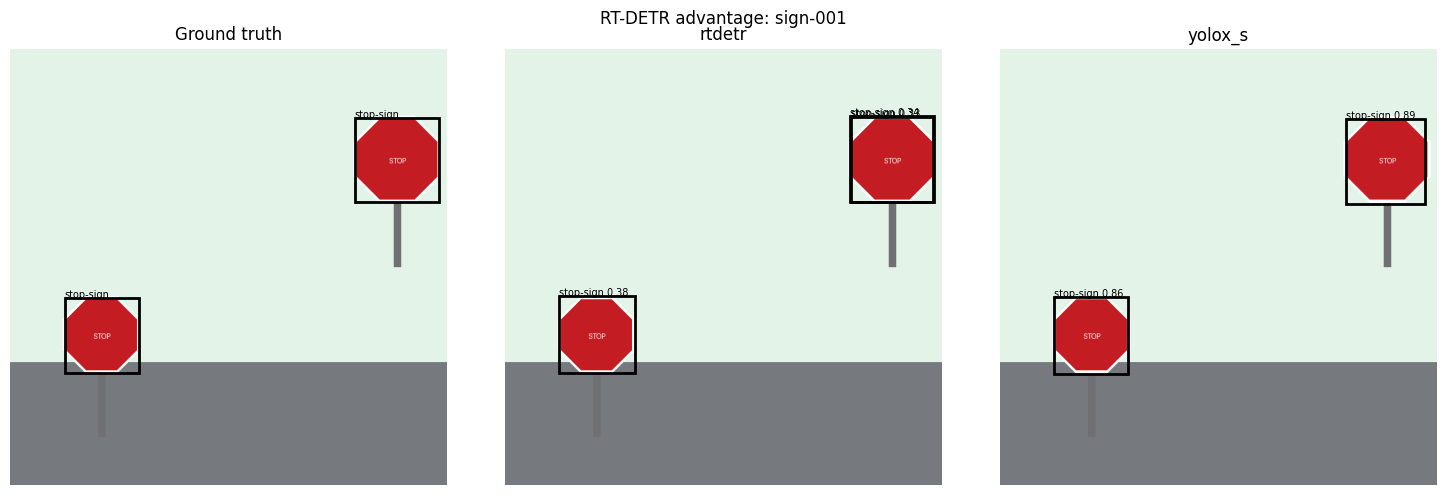

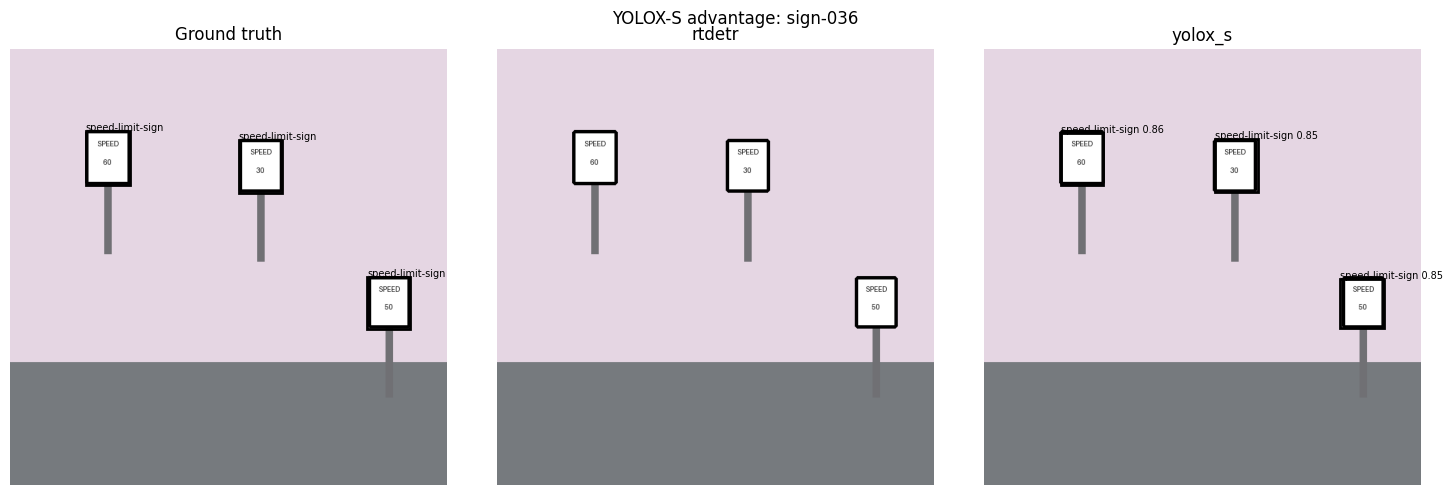

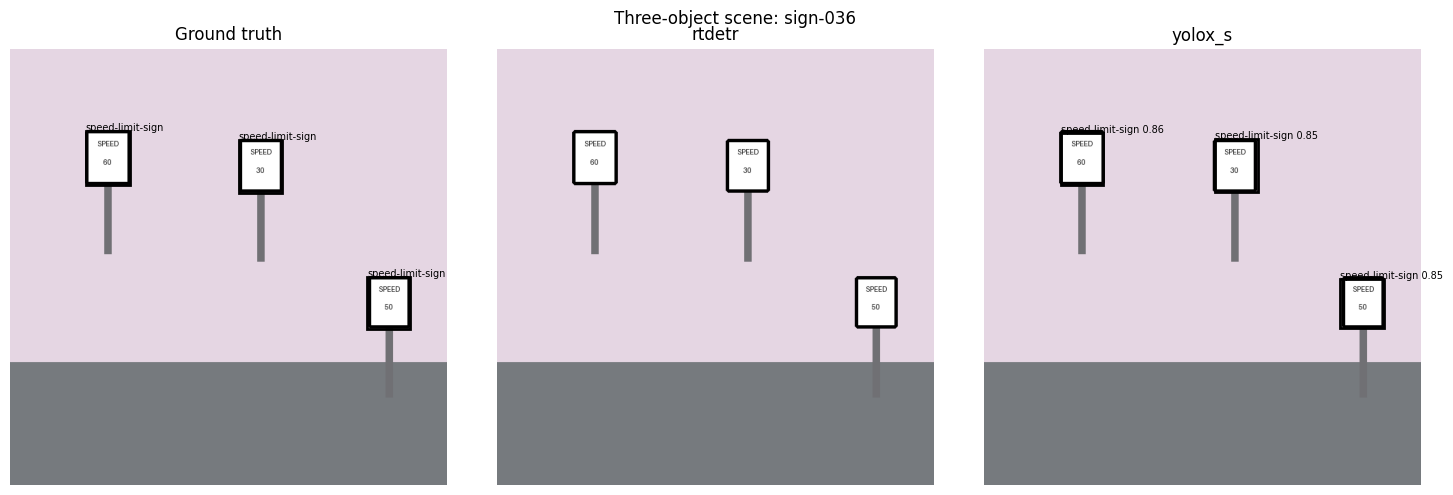

In [21]:
# @title Plot deterministic comparison examples
if "rtdetr" in MODEL_KEYS and "yolox_s" in MODEL_KEYS:
    candidates=[
        ("RT-DETR advantage",int(disagreements["rtdetr_advantage"].idxmax())),
        ("YOLOX-S advantage",int(disagreements["rtdetr_advantage"].idxmin())),
        ("Three-object scene",next((i for i,r in enumerate(test_records) if len(r["boxes"])==3),0)),
    ]

    for title,idx in candidates:
        record=test_records[idx]
        fig,axes=plt.subplots(1,3,figsize=(15,5))

        for ax in axes:
            ax.imshow(record["image"]);ax.axis("off")

        axes[0].set_title("Ground truth")
        for box,label in zip(record["boxes"],record["labels"]):
            x0,y0,x1,y1=box
            axes[0].add_patch(plt.Rectangle((x0,y0),x1-x0,y1-y0,fill=False,linewidth=2))
            axes[0].text(x0,y0,label,fontsize=7)

        for ax,key in zip(axes[1:],("rtdetr","yolox_s")):
            ax.set_title(key)
            for det in test_predictions[(key,"adapted")][idx]:
                if det["score"]<DISPLAY_THRESHOLD:continue
                x0,y0,x1,y1=det["box"]
                ax.add_patch(plt.Rectangle((x0,y0),x1-x0,y1-y0,fill=False,linewidth=2))
                ax.text(x0,y0,f"{det['label']} {det['score']:.2f}",fontsize=7)

        fig.suptitle(f"{title}: {record['id']}")
        plt.tight_layout()
        safe=title.lower().replace(" ","_")
        plt.savefig(OUTPUT_ROOT/"figures"/f"gallery_{safe}.png",dpi=150,bbox_inches="tight")
        plt.show()

# 17. Computational tradeoffs

No composite winner is calculated.

The practical comparison includes:

- base checkpoint size;
- total parameters;
- trainable parameters;
- training wall time;
- test inference latency;
- artifact size;
- AP/AP75.

YOLOX-X in `FULL` is specifically a **scale experiment**: larger is not assumed to be better on this small transfer task.

In [22]:
# @title Tradeoff table
tradeoff_rows=[]
for key in MODEL_KEYS:
    adapted=test_table[(test_table["model"]==key)&(test_table["state"]=="adapted")].iloc[0]
    report=training_reports[key]
    if key=="rtdetr":
        weight_bytes=RTDETR_SPEC["files"]["model.safetensors"][0]
    else:
        weight_bytes=YOLOX_VARIANTS[key]["bytes"]
    tradeoff_rows.append({
        "model":key,
        "weight_MiB":weight_bytes/2**20,
        "parameters_M":report["total_parameters"]/1e6,
        "trainable_M":report["trainable_parameters"]/1e6,
        "training_seconds":report["training_seconds"],
        "ms_per_test_image":adapted["ms_per_image"],
        "artifact_MiB":artifact_descriptors[key]["bytes"]/2**20,
        "test_ap":adapted["ap"],
        "test_ap75":adapted["ap75"],
    })

tradeoffs=pd.DataFrame(tradeoff_rows)
display(tradeoffs)
tradeoffs.to_csv(OUTPUT_ROOT/"test"/"computational_tradeoffs.csv",index=False)

,model,weight_MiB,parameters_M,trainable_M,training_seconds,ms_per_test_image,artifact_MiB,test_ap,test_ap75
0,rtdetr,164.199692,42.733137,19.259121,16.302030,84.101266,166.813025,0.973711,0.988299
1,yolox_s,68.749547,8.938456,1.891096,5.742115,18.722947,34.323276,0.851974,1.000000


# 18. Fresh reload parity

Test evaluation above already used freshly reconstructed artifact-backed models.

The next cell additionally verifies one fixed validation image at the raw-output boundary:

- same detection count;
- same class labels;
- box coordinates within tolerance;
- scores within tolerance.

In [23]:
# @title Artifact reload parity on a fixed validation image
parity={}
verify_record=validation_records[0]

for key in MODEL_KEYS:
    # `fresh_adapted` was reconstructed from the artifact before test.
    reloaded=fresh_adapted[key]

    a=live_parity_predictions[key]
    b=reloaded.detect(verify_record["image"],DISPLAY_THRESHOLD)

    if len(a)!=len(b):
        raise RuntimeError(f"{key}: reload detection count mismatch")
    max_box=max_score=0.0
    for da,db in zip(a,b):
        if da["label"]!=db["label"]:
            raise RuntimeError(f"{key}: reload label mismatch")
        max_box=max(max_box,max(abs(x-y) for x,y in zip(da["box"],db["box"])))
        max_score=max(max_score,abs(da["score"]-db["score"]))

    parity[key]={
        "n_detections":len(a),
        "max_abs_box_difference":max_box,
        "max_abs_score_difference":max_score,
    }
    if max_box>1e-4 or max_score>1e-6:
        raise RuntimeError(f"{key}: reload parity exceeded tolerance")

print(parity)

{'rtdetr': {'n_detections': 1, 'max_abs_box_difference': 0.0, 'max_abs_score_difference': 0.0}, 'yolox_s': {'n_detections': 1, 'max_abs_box_difference': 0.0, 'max_abs_score_difference': 0.0}}


# 19. New-seed inference sanity check

Three synthetic scenes are generated using seed `2026`, completely outside the train/validation/test fixture.

Their exact boxes are known, so same-label IoU can be shown as an additional sanity check.

These examples do **not** enter the main test metrics.

In [24]:
# @title New-seed examples
new_records=generate_sign_dataset(3,NEW_DATA_SEED,MAX_OBJECTS)

new_rows=[]
for key in MODEL_KEYS:
    model=fresh_adapted[key]
    preds=model.predict_many(new_records,EVAL_SCORE_THRESHOLD)
    op=operating_metrics(preds,new_records,DISPLAY_THRESHOLD)
    new_rows.append({"model":key,**op})
    for i,(record,dets) in enumerate(zip(new_records,preds)):
        payload={
            "image_id":record["id"],
            "detections":[d for d in dets if d["score"]>=DISPLAY_THRESHOLD],
        }
        (OUTPUT_ROOT/"new_data"/f"{key}_{i}.json").write_text(
            json.dumps(payload,indent=2),encoding="utf-8"
        )

display(pd.DataFrame(new_rows))

,model,precision50,recall50,mean_matched_iou,false_positives_per_image,missed_objects_per_image
0,rtdetr,1.0,0.714286,0.965272,0.0,0.666667
1,yolox_s,1.0,1.000000,0.928638,0.0,0.000000


## Optional BYOD — same three-class adaptation task

Set `USE_BYOD=True` and a local `BYOD_ZIP_PATH`. Supply 5–60 images and `annotations.csv`: `image_id,file,label,x0,y0,x1,y1[,split]`, one row per box, at most six boxes per image. Only `stop-sign`, `yield-sign`, `speed-limit-sign` are supported. Every image must be annotated; each split must contain all three classes. Supply all train/validation/test assignments or omit every assignment for the deterministic 60/20/20 split. Pixels must not repeat across splits. Images must be 16–4096 pixels per side and at most 16 megapixels.

Validation fails before models load. A separate run directory records input digests, bounded training, validation, frozen settings, exported adapters, live-to-fresh parity, baseline and adapted test results, and inference. Model instances run sequentially; the canonical tables and artifacts remain separate. This implementation still needs real-model BYOD qualification on the supported T4 runtime. Synthetic success does not establish road-scene performance.


In [25]:
# @title Optional BYOD: validate, adapt, freeze, reload, evaluate and export
import csv
import zipfile
import tempfile
import traceback
from pathlib import PurePosixPath

MAX_BYOD_IMAGES=60
MAX_LABELS_PER_IMAGE=6

def safe_extract_zip(zip_path,destination):
    parent=Path(destination)
    parent.mkdir(parents=True,exist_ok=True)
    with zipfile.ZipFile(zip_path) as archive:
        infos=archive.infolist()
        if len(infos)>1000 or sum(i.file_size for i in infos)>2*1024**3:
            raise ValueError("BYOD ZIP exceeds member or expanded-size limit")
        names=set()
        for info in infos:
            path=PurePosixPath(info.filename)
            if (not info.filename or '\\' in info.filename or ':' in info.filename
                    or path.is_absolute() or '..' in path.parts):
                raise ValueError("unsafe ZIP path")
            name=str(path).casefold()
            if name in names: raise ValueError("duplicate ZIP member")
            names.add(name)
            if (info.external_attr>>16)&0o170000==0o120000:
                raise ValueError("symlink member refused")
        root=Path(tempfile.mkdtemp(prefix='dataset-',dir=parent))
        archive.extractall(root)
    return root

def load_byod(zip_path):
    root=safe_extract_zip(zip_path,WORK_ROOT/'byod')
    candidates=list(root.rglob('annotations.csv'))
    if len(candidates)!=1: raise ValueError('Exactly one annotations.csv required')
    annotation=candidates[0]
    base=annotation.parent.resolve()
    with annotation.open(encoding='utf-8-sig',newline='') as stream:
        reader=csv.DictReader(stream)
        required={'image_id','file','label','x0','y0','x1','y1'}
        if not required<=set(reader.fieldnames or []): raise ValueError('Missing annotation columns')
        rows=list(reader)
    if not rows or len(rows)>MAX_BYOD_IMAGES*MAX_LABELS_PER_IMAGE:
        raise ValueError('Empty or oversized annotations')
    records={}; owners={}
    for row in rows:
        rid=row['image_id'].strip(); filename=row['file'].strip()
        split=row.get('split','').strip().lower()
        rel=PurePosixPath(filename)
        if not rid or not filename or rel.is_absolute() or '..' in rel.parts or '\\' in filename or ':' in filename:
            raise ValueError('Invalid image identity or path')
        path=(base/filename).resolve()
        if base not in path.parents or not path.is_file(): raise ValueError('Missing or unsafe image')
        if row['label'] not in CLASS_NAMES: raise ValueError('Unsupported class; use the three declared sign labels')
        if split not in ('','train','validation','test'): raise ValueError('Invalid split')
        if path in owners and owners[path]!=rid: raise ValueError('One file has multiple image IDs')
        owners[path]=rid
        if rid not in records:
            with Image.open(path) as original:
                if not all(16<=side<=4096 for side in original.size) or original.width*original.height>16_000_000:
                    raise ValueError('Image dimensions outside 16..4096 / 16MP bound')
                image=original.convert('RGB')
            records[rid]={'id':rid,'image':image,'boxes':[],'labels':[], 'split':split,
                'file':filename,'sha256':hashlib.sha256(path.read_bytes()).hexdigest(),
                'pixel_sha256':hashlib.sha256(str(image.size).encode()+image.tobytes()).hexdigest()}
        r=records[rid]
        if r['file']!=filename or r['split']!=split: raise ValueError('Inconsistent file/split for image ID')
        box=[float(row[c]) for c in ('x0','y0','x1','y1')]
        w,h=r['image'].size
        if not all(np.isfinite(box)) or not (0<=box[0]<box[2]<=w and 0<=box[1]<box[3]<=h):
            raise ValueError('Nonfinite or out-of-bounds box')
        if any(box==b and row['label']==label for b,label in zip(r['boxes'],r['labels'])):
            raise ValueError('Duplicate annotation')
        r['boxes'].append(box); r['labels'].append(row['label'])
        if len(r['boxes'])>MAX_LABELS_PER_IMAGE: raise ValueError('More than six labels per image')
    records=sorted(records.values(),key=lambda r:r['id'])
    if not 5<=len(records)<=MAX_BYOD_IMAGES: raise ValueError('BYOD requires 5..60 images')
    image_files={p.resolve() for p in root.rglob('*') if p.suffix.lower() in {'.png','.jpg','.jpeg','.webp','.bmp','.tif','.tiff'}}
    if image_files!=set(owners): raise ValueError('Every archive image must be annotated exactly once by ID')
    if any(r['split'] for r in records) and not all(r['split'] for r in records):
        raise ValueError('Supply splits for every image or none')
    if not records[0]['split']:
        order=np.random.default_rng(SPLIT_SEED).permutation(len(records))
        a=int(.6*len(records)); b=int(.8*len(records))
        for index,pos in enumerate(order): records[pos]['split']='train' if index<a else 'validation' if index<b else 'test'
    hashes={}
    for r in records:
        old=hashes.setdefault(r['pixel_sha256'],r['split'])
        if old!=r['split']: raise ValueError('Duplicate pixels across splits')
    for split in ('train','validation','test'):
        labels={label for r in records if r['split']==split for label in r['labels']}
        if labels!=set(CLASS_NAMES): raise ValueError(f'{split} must contain all three classes')
    return records

def assert_byod_parity(a,b):
    if len(a)!=len(b): raise RuntimeError('BYOD reload count differs')
    for x,y in zip(a,b):
        if x['label']!=y['label'] or not np.allclose(x['box'],y['box'],rtol=0,atol=1e-4) or abs(x['score']-y['score'])>1e-6:
            raise RuntimeError('BYOD live-to-reload parity failed')

def run_byod_model(key,records,run_root):
    train=[r for r in records if r['split']=='train']
    validation=[r for r in records if r['split']=='validation']
    test=[r for r in records if r['split']=='test']
    folder=run_root/key; folder.mkdir()
    pipe=None; fresh=None
    try:
        pipe=(RTDETRWorkshop.from_pretrained(CLASS_NAMES,seed=0,device=DEVICE) if key=='rtdetr'
              else YOLOXWorkshop.from_pretrained(key,CLASS_NAMES,seed=0,device=DEVICE))
        baseline_validation=average_precision(pipe.predict_many(validation,EVAL_SCORE_THRESHOLD),validation,CLASS_NAMES)
        if key=='rtdetr':
            training=pipe.finetune(train,epochs=RTDETR_EPOCHS,batch_size=RTDETR_BATCH_SIZE,learning_rate=RTDETR_LEARNING_RATE,seed=0)
        else:
            training=pipe.finetune(train,epochs=YOLOX_EPOCHS,batch_size=YOLOX_BATCH_SIZE,learning_rate=YOLOX_LEARNING_RATE,seed=0)
        validation_metrics=average_precision(pipe.predict_many(validation,EVAL_SCORE_THRESHOLD),validation,CLASS_NAMES)
        live=pipe.detect(validation[0]['image'],DISPLAY_THRESHOLD)
        artifact=folder/'adapter.pt'; descriptor=pipe.save_artifact(artifact)
        artifact_hash=hashlib.sha256(artifact.read_bytes()).hexdigest()
        frozen={'model':key,'classes':list(CLASS_NAMES),'training':training,'artifact':descriptor,
                'artifact_sha256':artifact_hash,'baseline_validation':baseline_validation,'adapted_validation':validation_metrics,
                'evaluation_score_threshold':EVAL_SCORE_THRESHOLD,'display_threshold':DISPLAY_THRESHOLD,
                'input_manifest':'../input_manifest.json'}
        (folder/'frozen_experiment.json').write_text(json.dumps(frozen,indent=2,default=str),encoding='utf-8')
        pipe=None; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        pipe=(RTDETRWorkshop.from_pretrained(CLASS_NAMES,seed=0,device=DEVICE) if key=='rtdetr'
              else YOLOXWorkshop.from_pretrained(key,CLASS_NAMES,seed=0,device=DEVICE))
        baseline_test=pipe.predict_many(test,EVAL_SCORE_THRESHOLD)
        pipe=None; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        if hashlib.sha256(artifact.read_bytes()).hexdigest()!=artifact_hash: raise RuntimeError('Artifact changed')
        fresh=(RTDETRWorkshop.load_artifact(artifact,DEVICE) if key=='rtdetr' else YOLOXWorkshop.load_artifact(artifact,DEVICE))
        assert_byod_parity(live,fresh.detect(validation[0]['image'],DISPLAY_THRESHOLD))
        adapted_test=fresh.predict_many(test,EVAL_SCORE_THRESHOLD)
        metrics=[]
        for state,predictions in [('pre',baseline_test),('adapted',adapted_test)]:
            metrics.append({'model':key,'state':state,**average_precision(predictions,test,CLASS_NAMES),
                            **operating_metrics(predictions,test,DISPLAY_THRESHOLD)})
        payload={'metrics':metrics,'parity':'live-to-fresh PASS','test_ids':[r['id'] for r in test],
                 'baseline_predictions':baseline_test,'adapted_predictions':adapted_test,
                 'inference_example':fresh.detect(test[0]['image'],DISPLAY_THRESHOLD)}
        (folder/'results.json').write_text(json.dumps(payload,indent=2,default=str),encoding='utf-8')
        pd.DataFrame(metrics).to_csv(folder/'metrics.csv',index=False)
        return metrics
    except Exception as exc:
        traceback.clear_frames(exc.__traceback__)
        raise
    finally:
        pipe=None; fresh=None; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

if USE_BYOD:
    if not BYOD_ZIP_PATH: raise ValueError('Set BYOD_ZIP_PATH for noninteractive execution')
    byod_records=load_byod(BYOD_ZIP_PATH)  # All validation precedes model acquisition/adaptation.
    for alias in ('pipe','model','adapted','reloaded','again','fresh_adapted'):
        globals().pop(alias,None)
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    byod_parent=OUTPUT_ROOT/'byod'; byod_parent.mkdir(exist_ok=True)
    byod_run=Path(tempfile.mkdtemp(prefix='run-',dir=byod_parent))
    manifest={'zip_sha256':hashlib.sha256(Path(BYOD_ZIP_PATH).read_bytes()).hexdigest(),
              'records':[{k:v for k,v in r.items() if k!='image'} for r in byod_records],
              'runtime':{'python':sys.version,'torch':torch.__version__,'device':str(DEVICE)},
              'models':frozen_experiment['models'],
              'split_seed':SPLIT_SEED,'scope':'three-class bounded adaptation; separate from canonical results'}
    (byod_run/'input_manifest.json').write_text(json.dumps(manifest,indent=2),encoding='utf-8')
    byod_metrics=[row for key in MODEL_KEYS for row in run_byod_model(key,byod_records,byod_run)]
    pd.DataFrame(byod_metrics).to_csv(byod_run/'metrics.csv',index=False)
    display(pd.DataFrame(byod_metrics)); print('BYOD exports:',byod_run)
else:
    print('BYOD disabled; canonical synthetic E2E path completed.')


BYOD disabled; canonical synthetic E2E path completed.


## BYOD privacy

User-supplied imagery and annotations are processed inside the selected notebook runtime and are not sent to DIMER workers or APIs.

A hosted notebook is still an external compute environment. Do not upload confidential, biometric, surveillance, personal, security-sensitive, restricted, or proprietary imagery unless authorized.

# 21. Interpretation and limits

### Synthetic domain

These are rendered signs, not photographs.

High AP means that bounded adaptation learned this controlled rendering domain. It does not establish performance on real traffic signs.

### Small test set

Twelve images are sample-sanity evidence, not a benchmark.

### Different model-native recipes

This notebook compares **qualified detector systems**, not architecture under one optimizer.

RT-DETR and YOLOX differ in:

- prediction representation;
- matching/assignment;
- loss;
- optimizer;
- trainable surface;
- post-processing.

### AP50 can hide localization differences

AP50 may saturate. Read AP75 and AP@[.50:.95] alongside it.

### Scores are not calibrated probabilities

RT-DETR's class sigmoid and YOLOX's objectness × class score have different semantics.

### Closed vocabulary

After adaptation, this exercise's detectors recognize only:

- stop-sign
- yield-sign
- speed-limit-sign

They cannot accept a new text label at inference time.

That limitation motivates the subsequent **Open-Vocabulary Detection & Counting** workshop.

# 22. Exercises

### Exercise A — set prediction versus dense detection

Why does RT-DETR not require conventional NMS while YOLOX does?

### Exercise B — AP50 versus AP75

If two detectors both reach AP50 = 1.0, can one still localize boxes more accurately?

### Exercise C — bigger YOLOX

In `FULL`, does the 99M-parameter YOLOX-X outperform the 9M-parameter YOLOX-S on this small task?

Do not assume the answer before running it.

### Exercise D — score threshold

What changes when display threshold moves from 0.05 to 0.70?

Why should test data never be used to choose that operating point?

### Exercise E — production transfer

What labelled evidence would be required before adapting either detector to real Philippine road-sign imagery?

**Evaluation checkpoint.** **Optional controlled activity — Predict → Change one thing → Run → Observe → Explain.** After the canonical run, use the already computed validation predictions to compare the existing threshold-sweep rows at 0.30 and 0.50. Predict which changes more: precision or recall. Change only the display threshold in a separate scratch cell calling `operating_metrics(post_validation_predictions[key], validation_records, 0.50)` with `key="rtdetr"`; run and compare with 0.30. Record both values and explain misses versus false positives. Do not overwrite `DISPLAY_THRESHOLD`, frozen settings, test outputs, or retrain. No model reload is needed.


# 23. Export provenance and report

In [26]:
# @title Final provenance
import datetime

experiment_manifest={
    "notebook_spec":"2.1",
    "notebook_profile":"E2E",
    "notebook_mode":"WORKSHOP",
    "workshop_revision":"0.1.0-candidate",
    "timestamp_utc":datetime.datetime.now(datetime.timezone.utc).isoformat(),
    "execution_tier":WORKSHOP_TIER,
    "dataset":dataset_manifest,
    "models":frozen_experiment["models"],
    "evaluation":frozen_experiment["evaluation"],
    "training_reports":training_reports,
    "test_metrics":test_table.to_dict("records"),
    "artifact_parity":parity,
    "standalone_contract":{
        "dimer_git_clone_required":False,
        "dimer_source_runtime_fetch_required":False,
        "dimer_service_required":False,
        "credentials_required":False,
        "default_upload_required":False,
    },
    "candidate_release_gates":[
        "real-model BYOD valid and invalid path evidence",
        "fresh T4 Run all for STANDARD",
        "fresh T4 Run all for FULL",
        "record exact peak VRAM and wall time",
    ],
    "evidence_scope":"60 deterministic rendered sign scenes; 36 train / 12 validation / 12 independent test",
}

(OUTPUT_ROOT/"provenance"/"experiment_manifest.json").write_text(
    json.dumps(experiment_manifest,indent=2,default=str),encoding="utf-8"
)
(OUTPUT_ROOT/"workshop_summary.json").write_text(
    json.dumps({
        "tier":WORKSHOP_TIER,
        "models":MODEL_KEYS,
        "dataset_sha256":dataset_manifest["dataset_sha256"],
        "test_metrics":test_table.to_dict("records"),
        "artifacts":artifact_descriptors,
        "reload_parity":parity,
    },indent=2,default=str),
    encoding="utf-8"
)

import shutil
bundle=shutil.make_archive(
    str(Path(OUTPUT_DIR).resolve())+"_DIMER_Closed_Set_Detection_Workshop_Report",
    "zip",
    root_dir=Path(OUTPUT_DIR).resolve(),
)
print({"bundle":bundle,"sha256":sha256_file(bundle)})

{'bundle': '/content/outputs_DIMER_Closed_Set_Detection_Workshop_Report.zip', 'sha256': '088035734b39693f2d8ca32d64935e2ed7555d0a81eea2a7efaf7d6edf6b2ab9'}


# 24. Troubleshooting

| Symptom | Likely cause | Corrective action |
|---|---|---|
| CUDA unavailable | CPU runtime selected | choose a T4-class runtime before `Run all` |
| RT-DETR digest mismatch | incomplete/changed Hub asset | remove cached snapshot and retry; never bypass digest |
| YOLOX source digest mismatch | pinned upstream file changed/incorrect response | stop; never execute unverified source |
| YOLOX checkpoint digest mismatch | incomplete/changed release asset | remove cached checkpoint and retry |
| YOLOX OOM during SimOTA | label-assignment memory pressure | use canonical T4/batch size; do not change test protocol silently |
| one class absent from a split | canonical/BYOD split invalid | supply more data or explicit split; do not move boxes ad hoc |
| AP50 high but AP low | boxes not tight enough at stricter IoU thresholds | inspect localization, not only class hits |
| training loss decreases but validation AP does not | optimization did not transfer | keep the fixed recipe and interpret the result |
| reload parity fails | artifact/base mismatch or nondeterministic boundary | refuse the artifact and inspect identity/state |
| BYOD geometry differs between models | RT-DETR squash vs YOLOX letterbox | interpret BYOD as system-level rather than architecture-only comparison |

Failure should remain explicit rather than silently changing the detection problem.

# Glossary

| Term | Meaning |
|---|---|
| **Closed-set detector** | Detector with a fixed learned class vocabulary |
| **Bounding box** | Axis-aligned `[x0,y0,x1,y1]` rectangle around an object |
| **IoU** | Intersection-over-union between predicted and reference boxes |
| **AP** | Mean average precision across IoU thresholds 0.50–0.95 |
| **AP50** | AP using IoU ≥ 0.50 |
| **AP75** | AP using IoU ≥ 0.75 |
| **Object query** | Learned RT-DETR decoder query that can predict one object |
| **Objectness** | YOLOX estimate that a candidate location contains an object |
| **SimOTA** | YOLOX dynamic target-assignment procedure |
| **NMS** | Non-maximum suppression used to remove overlapping dense predictions |
| **Set prediction** | DETR-style formulation predicting a bounded object set without conventional NMS |
| **Re-head** | Replace/reinitialize the classification head for a new vocabulary |
| **Sample-sanity evidence** | Bounded tutorial evidence, not a deployment benchmark |

In [27]:
# @title Run-all completion summary
summary={
    "notebook_spec":"2.1",
    "profile":"E2E",
    "mode":"WORKSHOP",
    "tier":WORKSHOP_TIER,
    "models":MODEL_KEYS,
    "dataset_sha256":dataset_manifest["dataset_sha256"],
    "split_counts":{k:len(v) for k,v in splits.items()},
    "artifacts":artifact_descriptors,
    "reload_parity":parity,
    "output_directory":str(OUTPUT_ROOT.resolve()),
    "release_status":"candidate",
}
display(pd.Series(summary,name="value").to_frame())
print(
    "Closed-set detection notebook complete. "
    "Interpret built-in metrics as synthetic sample-sanity evidence; "
    "release still requires fresh STANDARD/FULL T4 and real-model BYOD qualification."
)

,value
notebook_spec,2.1
profile,E2E
mode,WORKSHOP
tier,STANDARD
models,"[rtdetr, yolox_s]"
dataset_sha256,823df4cf634db78216dccf5a6988171248b844beb5303e...
split_counts,"{'train': 36, 'validation': 12, 'test': 12}"
artifacts,{'rtdetr': {'path': 'outputs/artifacts/rtdetr/...
reload_parity,"{'rtdetr': {'n_detections': 1, 'max_abs_box_di..."
output_directory,/content/outputs


Closed-set detection notebook complete. Interpret built-in metrics as synthetic sample-sanity evidence; release still requires fresh STANDARD/FULL T4 and real-model BYOD qualification.
